# IMPORT DATASET

In [ ]:
import pandas as pd
from google.colab import files

# Step 2: Upload CSV file
uploaded = files.upload()  # Choose your CSV file

# Step 3: Get the uploaded file name
file_name = list(uploaded.keys())[0]

# Step 4: Read CSV file
df = pd.read_csv(file_name)

# Step 5: Display the data
df

Saving BEED_Data.csv to BEED_Data.csv


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0
3,68,104,73,34,-12,-26,-38,-36,-67,-88,-25,31,18,-4,6,-29,0
4,-67,-90,-97,-94,-86,-71,-43,-11,23,46,58,50,39,19,-9,-41,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,-9,-4,-7,2,-9,-14,-7,12,-5,-3,-2,-2,-12,-5,4,1,3
7996,-8,-4,-7,1,-8,-14,-7,12,-6,-3,-2,-3,-15,-4,4,1,3
7997,-6,-5,-7,1,-8,-14,-7,12,-7,-3,-2,-4,-16,-4,3,1,3
7998,-5,-6,-6,1,-8,-13,-7,13,-7,-2,-3,-5,-15,-4,3,0,3


# COUNT OF CLASS

In [ ]:
# Count number of samples for each class y = 0 to 3
class_counts = df['y'].value_counts().sort_index()

print(class_counts)

y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64


# *Normalized* overlay (clean comparison)

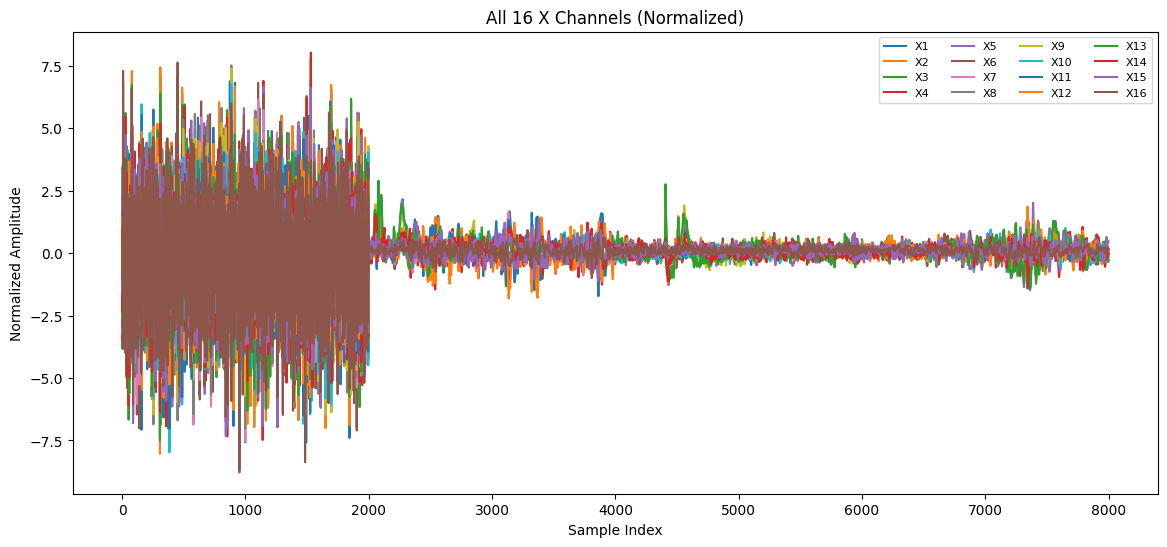

In [ ]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
channels_scaled = scaler.fit_transform(df.iloc[:, :16])

plt.figure(figsize=(14, 6))

for i in range(16):
    plt.plot(channels_scaled[:, i], label=f'X{i+1}')

plt.xlabel("Sample Index")
plt.ylabel("Normalized Amplitude")
plt.title("All 16 X Channels (Normalized)")
plt.legend(ncol=4, fontsize=8)
plt.show()

# Subplots (one channel per row — very clear)

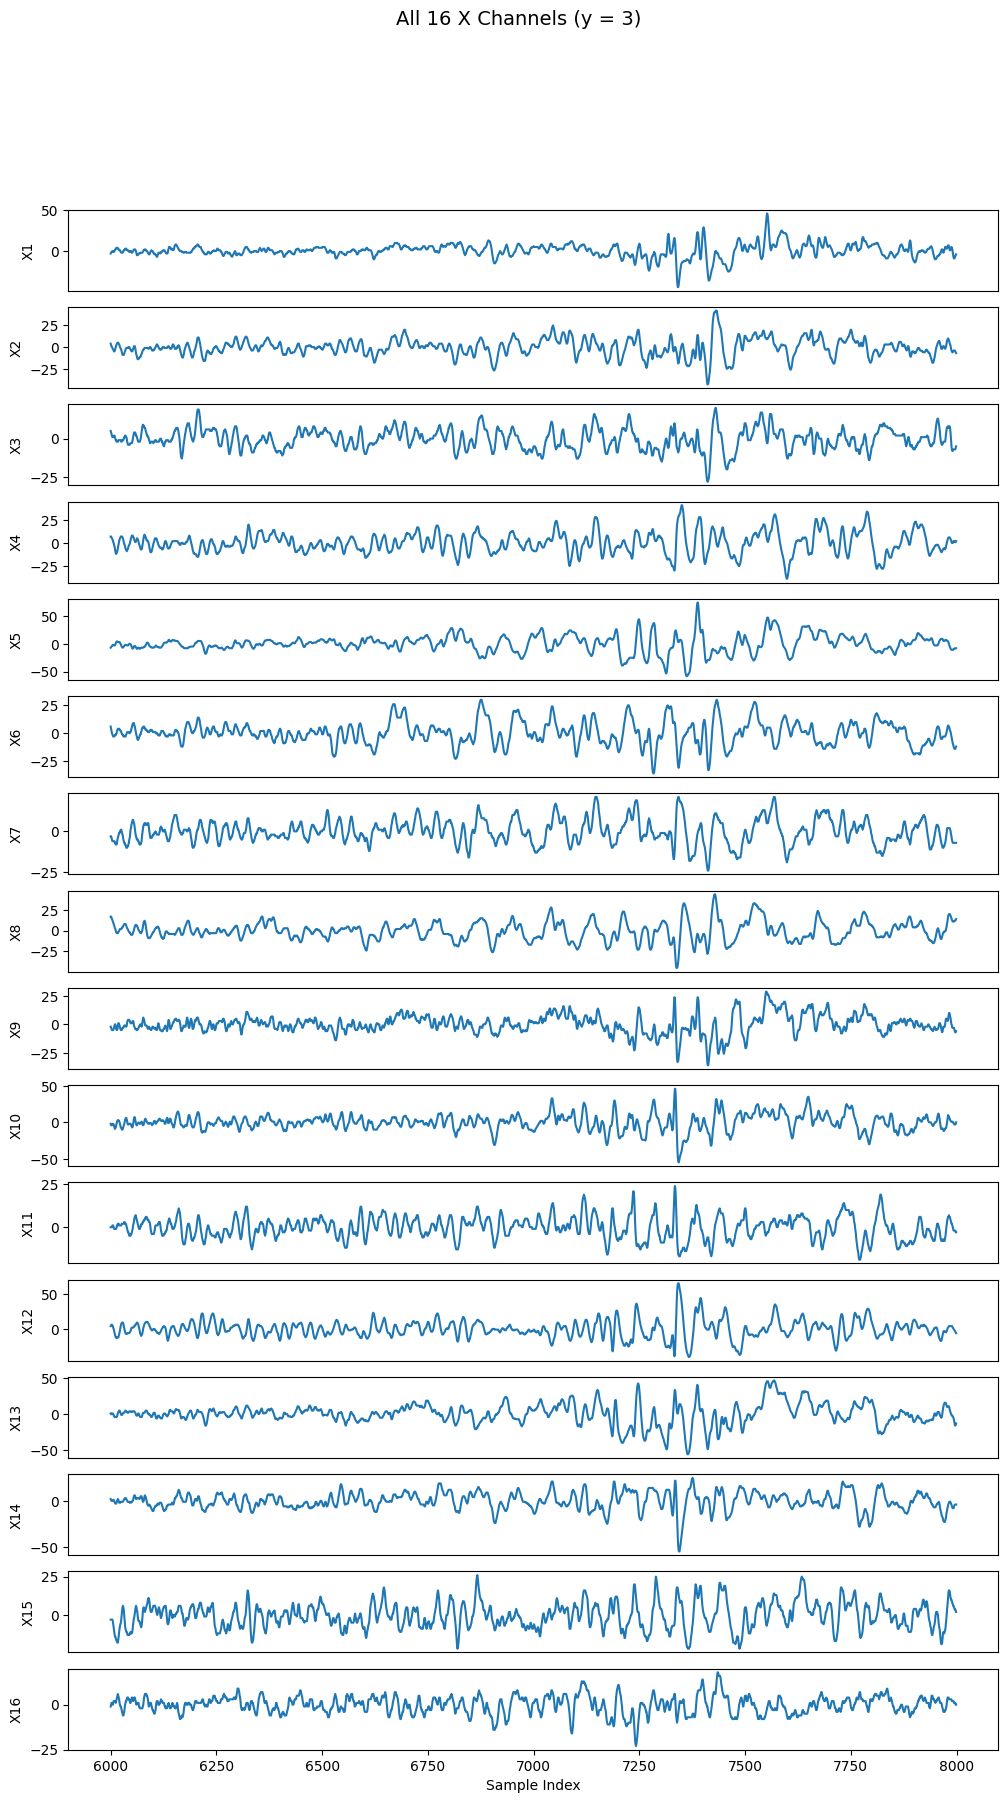

In [ ]:
channels = df[df['y'] == 3].iloc[:, :16]
x = channels.index

plt.figure(figsize=(12, 20))

for i, col in enumerate(channels.columns):
    ax = plt.subplot(16, 1, i + 1)
    ax.plot(x, channels[col])
    ax.set_ylabel(col)

    if i < 15:
        ax.set_xticks([])

ax.set_xlabel("Sample Index")
plt.suptitle("All 16 X Channels (y = 3)", fontsize=14)
plt.show()

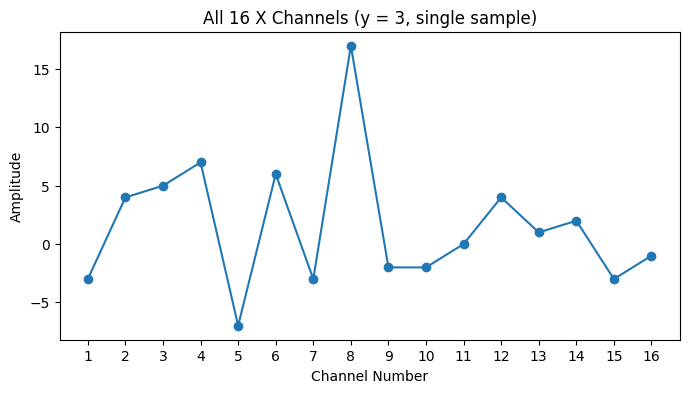

In [ ]:
sample_idx = 0  # first sample where y == 3
sample = channels.iloc[sample_idx]

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, 17), sample, marker='o')
plt.xticks(range(1, 17))
plt.xlabel("Channel Number")
plt.ylabel("Amplitude")
plt.title("All 16 X Channels (y = 3, single sample)")
plt.show()



# **ML for binary classification**

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, classification_report

# Classifiers
from sklearn.linear_model import (
    LogisticRegression, RidgeClassifier, SGDClassifier,
    Perceptron, PassiveAggressiveClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, AdaBoostClassifier,
    BaggingClassifier, HistGradientBoostingClassifier
)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
file_path = file_name # Corrected to use the uploaded file name
df = pd.read_csv(file_path)

# ------------------------------------------------------------
# 2. CONVERT TO BINARY CLASSIFICATION
# ------------------------------------------------------------
# In the BEED dataset, labels are often 'Normal', 'Interictal', 'Ictal'.
# We group 'Interictal' and 'Ictal' as "Abnormal" (1) vs 'Normal' (0).
X = df.iloc[:, :-1]
y_original = df.iloc[:, -1]

# Mapping logic: Keep 0 as Normal, make everything else 1
# Adjust strings/values based on your specific CSV's label column
y_binary = y_original.apply(lambda x: 0 if x == 0 else 1)

print(f"Original classes: {y_original.unique()}")
print(f"Binary distribution: \n{y_binary.value_counts()}")

# ------------------------------------------------------------
# 3. TRAIN-TEST-VAL SPLIT
# ------------------------------------------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp
)

# ------------------------------------------------------------
# 4. DEFINE MODELS (Parameters kept exactly as requested)
# ------------------------------------------------------------
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=42))
    ]),
    "Ridge Classifier": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RidgeClassifier())
    ]),
    "SGD Classifier": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SGDClassifier(random_state=42))
    ]),
    "Perceptron": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Perceptron(random_state=42))
    ]),
    "Passive Aggressive": Pipeline([
        ("scaler", StandardScaler()),
        ("model", PassiveAggressiveClassifier(random_state=42, max_iter=2000))
    ]),
    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(random_state=42, max_iter=10000))
    ]),
    "RBF SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", random_state=42))
    ]),
    "Gaussian Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Bagging": BaggingClassifier(random_state=42),
    "Linear Discriminant Analysis": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearDiscriminantAnalysis())
    ]),
    "Quadratic Discriminant Analysis": Pipeline([
        ("scaler", StandardScaler()),
        ("model", QuadraticDiscriminantAnalysis())
    ]),
    "MLP Neural Network": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42))
    ])
}

# ------------------------------------------------------------
# 5. TRAIN AND EVALUATE
# ------------------------------------------------------------
results = []
for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        # For binary classification, 'binary' average is often used for precision
        prec = precision_score(y_test, y_pred, average='binary', zero_division=0)

        results.append({
            "Algorithm": name,
            "Accuracy": acc,
            "Precision": prec
        })
        print(f"{name} - Accuracy: {acc:.4f}, Precision: {prec:.4f}")
    except Exception as e:
        print(f"{name} failed: {e}")

# ------------------------------------------------------------
# 6. RESULTS TABLE
# ------------------------------------------------------------
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print("\n================ BINARY RESULTS ================\n")
print(results_df)


Original classes: [0 1 2 3]
Binary distribution: 
y
1    6000
0    2000
Name: count, dtype: int64
Logistic Regression - Accuracy: 0.8037, Precision: 0.7957
Ridge Classifier - Accuracy: 0.7987, Precision: 0.7900
SGD Classifier - Accuracy: 0.8350, Precision: 0.8197
Perceptron - Accuracy: 0.7056, Precision: 0.8448
Passive Aggressive - Accuracy: 0.8006, Precision: 0.8003
K-Nearest Neighbors - Accuracy: 0.9938, Precision: 0.9917
Linear SVM - Accuracy: 0.7987, Precision: 0.7900
RBF SVM - Accuracy: 0.9956, Precision: 0.9942
Gaussian Naive Bayes - Accuracy: 0.9625, Precision: 0.9914
Decision Tree - Accuracy: 0.9906, Precision: 0.9917
Random Forest - Accuracy: 0.9962, Precision: 0.9958
Extra Trees - Accuracy: 0.9981, Precision: 0.9975
Gradient Boosting - Accuracy: 0.9950, Precision: 0.9934
Hist Gradient Boosting - Accuracy: 0.9981, Precision: 0.9975
AdaBoost - Accuracy: 0.9762, Precision: 0.9786
Bagging - Accuracy: 0.9944, Precision: 0.9958
Linear Discriminant Analysis - Accuracy: 0.8087, Preci

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, classification_report

# Classifiers
from sklearn.linear_model import (
    LogisticRegression, RidgeClassifier, SGDClassifier,
    Perceptron, PassiveAggressiveClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, AdaBoostClassifier,
    BaggingClassifier, HistGradientBoostingClassifier
)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
file_path = file_name # Corrected to use the uploaded file name
df = pd.read_csv(file_path)

# ------------------------------------------------------------
# 2. CONVERT TO BINARY CLASSIFICATION
# ------------------------------------------------------------
# In the BEED dataset, labels are often 'Normal', 'Interictal', 'Ictal'.
# We group 'Interictal' and 'Ictal' as "Abnormal" (1) vs 'Normal' (0).
X = df.iloc[:, :-1]
y_original = df.iloc[:, -1]

# Mapping logic: Keep 0 as Normal, make everything else 1
# Adjust strings/values based on your specific CSV's label column
y_binary = y_original.apply(lambda x: 0 if x == 0 else 1)

print(f"Original classes: {y_original.unique()}")
print(f"Binary distribution: \n{y_binary.value_counts()}")

# ------------------------------------------------------------
# 3. TRAIN-TEST-VAL SPLIT
# ------------------------------------------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp
)

# ------------------------------------------------------------
# 4. DEFINE MODELS (Parameters kept exactly as requested)
# ------------------------------------------------------------
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=42))
    ]),

    "Ridge Classifier": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RidgeClassifier())
    ]),

    "SGD Classifier": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SGDClassifier(random_state=42))
    ]),

    "Perceptron": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Perceptron(random_state=42))
    ]),

    "Passive Aggressive": Pipeline([
        ("scaler", StandardScaler()),
        ("model", PassiveAggressiveClassifier(random_state=42, max_iter=2000))
    ]),

    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(random_state=42, max_iter=10000))
    ]),

    "RBF SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", random_state=42))
    ]),

    "Gaussian Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ]),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=42),

    "AdaBoost": AdaBoostClassifier(random_state=42),

    "Bagging": BaggingClassifier(random_state=42),

    "Linear Discriminant Analysis": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearDiscriminantAnalysis())
    ]),

    "Quadratic Discriminant Analysis": Pipeline([
        ("scaler", StandardScaler()),
        ("model", QuadraticDiscriminantAnalysis())
    ]),

    "MLP Neural Network": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(100, 50),
            max_iter=1000,
            random_state=42
        ))
    ])
}

# ------------------------------------------------------------
# 5. TRAIN AND EVALUATE
# ------------------------------------------------------------
results = []
for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        # For binary classification, 'binary' average is often used for precision
        prec = precision_score(y_test, y_pred, average='binary', zero_division=0)

        results.append({
            "Algorithm": name,
            "Accuracy": acc,
            "Precision": prec
        })
        print(f"{name} - Accuracy: {acc:.4f}, Precision: {prec:.4f}")
    except Exception as e:
        print(f"{name} failed: {e}")

# ------------------------------------------------------------
# 6. RESULTS TABLE
# ------------------------------------------------------------
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print("\n================ BINARY RESULTS ================\n")
print(results_df)

Original classes: [0 1 2 3]
Binary distribution: 
y
1    6000
0    2000
Name: count, dtype: int64
Logistic Regression - Accuracy: 0.8037, Precision: 0.7957
Ridge Classifier - Accuracy: 0.7987, Precision: 0.7900
SGD Classifier - Accuracy: 0.8350, Precision: 0.8197
Perceptron - Accuracy: 0.7056, Precision: 0.8448
Passive Aggressive - Accuracy: 0.8006, Precision: 0.8003
K-Nearest Neighbors - Accuracy: 0.9938, Precision: 0.9917
Linear SVM - Accuracy: 0.7987, Precision: 0.7900
RBF SVM - Accuracy: 0.9956, Precision: 0.9942
Gaussian Naive Bayes - Accuracy: 0.9625, Precision: 0.9914
Decision Tree - Accuracy: 0.9906, Precision: 0.9917
Random Forest - Accuracy: 0.9962, Precision: 0.9958
Extra Trees - Accuracy: 0.9981, Precision: 0.9975
Gradient Boosting - Accuracy: 0.9950, Precision: 0.9934
Hist Gradient Boosting - Accuracy: 0.9981, Precision: 0.9975
AdaBoost - Accuracy: 0.9762, Precision: 0.9786
Bagging - Accuracy: 0.9944, Precision: 0.9958
Linear Discriminant Analysis - Accuracy: 0.8087, Preci

**ML for multiclass classification**

In [ ]:
# ============================================================
# EEG Classification on CSV Dataset
# - Evaluates multiple ML classifiers
# - Reports Accuracy and Precision
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, classification_report

# Classifiers
from sklearn.linear_model import (
    LogisticRegression,
    RidgeClassifier,
    SGDClassifier,
    Perceptron,
    PassiveAggressiveClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble федерации(
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
# Replace with your actual file path
file_path = file_name # Corrected to use the uploaded file name

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

# ------------------------------------------------------------
# 2. DEFINE FEATURES AND TARGET
# ------------------------------------------------------------
# Based on your dataset description:
# - Columns 1 to 16 = EEG features
# - Column 17 = target label
# If your dataset is different, adjust this section.

X = df.iloc[:, :-1]   # first 16 columns
y = df.iloc[:, -1]    # last column

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)
print("Unique classes:", sorted(y.unique()))

# ------------------------------------------------------------
# 3. ENCODE TARGET IF NEEDED
# ------------------------------------------------------------
# If target is already numeric (0,1,2,3), this still works fine.
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nEncoded classes mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"{cls} -> {i}")

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
# Step 1: Split into 70% train and 30% temporary (test + validation)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

# Step 2: Split temp into 20% test and 10% validation
# Since temp = 30%, we split it as:
# test = 20/30 = 0.6667
# val  = 10/30 = 0.3333

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp,
    test_size=1/3,   # 0.3333 → validation
    random_state=42,
    stratify=y_temp
)

# Check sizes
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("Validation size:", X_val.shape[0])

# ------------------------------------------------------------
# 5. DEFINE MODELS
# ------------------------------------------------------------
# For models sensitive to feature scaling, use StandardScaler in a pipeline.

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=42))
    ]),

    "Ridge Classifier": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RidgeClassifier())
    ]),

    "SGD Classifier": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SGDClassifier(random_state=42))
    ]),

    "Perceptron": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Perceptron(random_state=42))
    ]),

    "Passive Aggressive": Pipeline([
        ("scaler", StandardScaler()),
        ("model", PassiveAggressiveClassifier(random_state=42, max_iter=2000))
    ]),

    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(random_state=42, max_iter=10000))
    ]),

    "RBF SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", random_state=42))
    ]),

    "Gaussian Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ]),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=42),

    "AdaBoost": AdaBoostClassifier(random_state=42),

    "Bagging": BaggingClassifier(random_state=42),

    "Linear Discriminant Analysis": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearDiscriminantAnalysis())
    ]),

    "Quadratic Discriminant Analysis": Pipeline([
        ("scaler", StandardScaler()),
        ("model", QuadraticDiscriminantAnalysis())
    ]),

    "MLP Neural Network": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(100, 50),
            max_iter=1000,
            random_state=42
        ))
    ])
}

# ------------------------------------------------------------
# 6. TRAIN AND EVALUATE
# ------------------------------------------------------------
results = []

print("\nTraining models...\n")

for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)

        results.append({
            "Algorithm": name,
            "Accuracy": acc,
            "Precision_Weighted": prec_weighted,
            "Precision_Macro": prec_macro
        })

        print(f"{name}")
        print(f"  Accuracy           : {acc:.4f}")
        print(f"  Precision (weighted): {prec_weighted:.4f}")
        print(f"  Precision (macro)   : {prec_macro:.4f}")
        print("-" * 50)

    except Exception as e:
        print(f"{name} failed: {e}")
        print("-" * 50)

# ------------------------------------------------------------
# 7. RESULTS TABLE
# ------------------------------------------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\n================ FINAL RESULTS ================\n")
print(results_df)

# Save results
results_df.to_csv("eeg_classification_results.csv", index=False)
print("\nResults saved to: eeg_classification_results.csv")

# ------------------------------------------------------------
# 8. DETAILED REPORT FOR BEST MODEL
# ------------------------------------------------------------
best_model_name = results_df.iloc[0]["Algorithm"]
best_model = models[best_model_name]

best_model.fit(X_train, y_train)
best_pred = best_model.predict(X_test)

print(f"\nBest Model: {best_model_name}")
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    best_pred,
    target_names=[str(c) for c in label_encoder.classes_],
    zero_division=0
))

SyntaxError: invalid syntax (3984663784.py, line 30)

**multiclass with parameters twick**

In [ ]:
# ============================================================
# EEG Classification on CSV Dataset
# - Evaluates multiple ML classifiers
# - Reports Accuracy and Precision
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, classification_report

# Classifiers
from sklearn.linear_model import (
    LogisticRegression,
    RidgeClassifier,
    SGDClassifier,
    Perceptron,
    PassiveAggressiveClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
# Replace with your actual file path
file_path = file_name # Corrected to use the uploaded file name

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

# ------------------------------------------------------------
# 2. DEFINE FEATURES AND TARGET
# ------------------------------------------------------------
# Based on your dataset description:
# - Columns 1 to 16 = EEG features
# - Column 17 = target label
# If your dataset is different, adjust this section.

X = df.iloc[:, :-1]   # first 16 columns
y = df.iloc[:, -1]    # last column

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)
print("Unique classes:", sorted(y.unique()))

# ------------------------------------------------------------
# 3. ENCODE TARGET IF NEEDED
# ------------------------------------------------------------
# If target is already numeric (0,1,2,3), this still works fine.
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nEncoded classes mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"{cls} -> {i}")

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
# Step 1: Split into 70% train and 30% temporary (test + validation)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

# Step 2: Split temp into 20% test and 10% validation
# Since temp = 30%, we split it as:
# test = 20/30 = 0.6667
# val  = 10/30 = 0.3333

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp,
    test_size=1/3,   # 0.3333 → validation
    random_state=42,
    stratify=y_temp
)

# Check sizes
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("Validation size:", X_val.shape[0])

# ------------------------------------------------------------
# 5. DEFINE MODELS
# ------------------------------------------------------------
# For models sensitive to feature scaling, use StandardScaler in a pipeline.

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=42))
    ]),
    "Ridge Classifier": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RidgeClassifier())
    ]),
    "SGD Classifier": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SGDClassifier(random_state=42))
    ]),
    "Perceptron": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Perceptron(random_state=42))
    ]),
    "Passive Aggressive": Pipeline([
        ("scaler", StandardScaler()),
        ("model", PassiveAggressiveClassifier(random_state=42, max_iter=2000))
    ]),
    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(random_state=42, max_iter=10000))
    ]),
    "RBF SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", random_state=42))
    ]),
    "Gaussian Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Bagging": BaggingClassifier(random_state=42),
    "Linear Discriminant Analysis": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearDiscriminantAnalysis())
    ]),
    "Quadratic Discriminant Analysis": Pipeline([
        ("scaler", StandardScaler()),
        ("model", QuadraticDiscriminantAnalysis())
    ]),
    "MLP Neural Network": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42))
    ])
}

# ------------------------------------------------------------
# 6. TRAIN AND EVALUATE
# ------------------------------------------------------------
results = []

print("\nTraining models...\n")

for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)

        results.append({
            "Algorithm": name,
            "Accuracy": acc,
            "Precision_Weighted": prec_weighted,
            "Precision_Macro": prec_macro
        })

        print(f"{name}")
        print(f"  Accuracy           : {acc:.4f}")
        print(f"  Precision (weighted): {prec_weighted:.4f}")
        print(f"  Precision (macro)   : {prec_macro:.4f}")
        print("-" * 50)

    except Exception as e:
        print(f"{name} failed: {e}")
        print("-" * 50)

# ------------------------------------------------------------
# 7. RESULTS TABLE
# ------------------------------------------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\n================ FINAL RESULTS ================\n")
print(results_df)

# Save results
results_df.to_csv("eeg_classification_results.csv", index=False)
print("\nResults saved to: eeg_classification_results.csv")

# ------------------------------------------------------------
# 8. DETAILED REPORT FOR BEST MODEL
# ------------------------------------------------------------
best_model_name = results_df.iloc[0]["Algorithm"]
best_model = models[best_model_name]

best_model.fit(X_train, y_train)
best_pred = best_model.predict(X_test)

print(f"\nBest Model: {best_model_name}")
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    best_pred,
    target_names=[str(c) for c in label_encoder.classes_],
    zero_division=0
))

Dataset shape: (8000, 17)

First 5 rows:
    X1   X2   X3   X4   X5   X6  X7  X8  X9  X10  X11  X12  X13  X14  X15  \
0    4    7   18   25   28   27  20  10 -10  -18  -20  -16   13   32   12   
1   87  114  120  106   76   54  28   5 -19  -49  -85 -102 -100  -89  -61   
2 -131 -133 -140 -131 -123 -108 -58 -51 -70  -77  -76  -76  -73  -57  -40   
3   68  104   73   34  -12  -26 -38 -36 -67  -88  -25   31   18   -4    6   
4  -67  -90  -97  -94  -86  -71 -43 -11  23   46   58   50   39   19   -9   

   X16  y  
0   10  0  
1  -21  0  
2  -14  0  
3  -29  0  
4  -41  0  

Feature shape: (8000, 16)
Target shape: (8000,)
Unique classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Encoded classes mapping:
0 -> 0
1 -> 1
2 -> 2
3 -> 3
Train size: 5600
Test size: 1600
Validation size: 800

Training models...

Logistic Regression
  Accuracy           : 0.4738
  Precision (weighted): 0.5068
  Precision (macro)   : 0.5068
--------------------------------------------------
Ridge Classifi

extra tree normal CV

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import ExtraTreesClassifier
import os # Import the os module

# Load dataset
file_path = file_name # Reverted to just the filename

df = pd.read_csv(file_path)

# Features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 7:2:1 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp
)

# Model
model = ExtraTreesClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

# Train
model.fit(X_train, y_train)

# Validation
y_val_pred = model.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
val_prec = precision_score(y_val, y_val_pred, average='weighted', zero_division=0)

# Test
y_test_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)

print("Extra Trees Results")
print("Validation Accuracy:", round(val_acc, 4))
print("Validation Precision:", round(val_prec, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Test Precision:", round(test_prec, 4))

print("\nClassification Report on Test Set:\n")
print(classification_report(y_test, y_test_pred, zero_division=0))
# Step 1: Cross-validation
cv_scores = cross_val_score(model, X, y_encoded, cv=5, scoring='accuracy')
print("Mean CV Accuracy:", cv_scores.mean())

# Step 2: Train
model.fit(X_train, y_train)

# Step 3: Validate
y_val_pred = model.predict(X_val)

# Step 4: Final test
y_test_pred = model.predict(X_test)

Extra Trees Results
Validation Accuracy: 0.9738
Validation Precision: 0.9745
Test Accuracy: 0.9844
Test Precision: 0.9845

Classification Report on Test Set:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       400
           1       0.99      0.98      0.99       400
           2       0.98      0.98      0.98       400
           3       0.97      0.98      0.97       400

    accuracy                           0.98      1600
   macro avg       0.98      0.98      0.98      1600
weighted avg       0.98      0.98      0.98      1600

Mean CV Accuracy: 0.758


WITH stringent nested cross-validation

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.ensemble import ExtraTreesClassifier

# Load dataset
file_path = file_name # Corrected to use the uploaded file name
df = pd.read_csv(file_path)

# Features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Base model
model = ExtraTreesClassifier(random_state=42, n_jobs=-1)

# Hyperparameter grid for inner CV
param_grid = {
    "n_estimators": [200, 500, 800],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [False, True]
}

# Inner CV for hyperparameter tuning
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Outer CV for unbiased evaluation
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search inside inner CV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="accuracy",
    cv=inner_cv,
    n_jobs=-1
)

# Nested CV
nested_scores = cross_validate(
    grid_search,
    X,
    y_encoded,
    cv=outer_cv,
    scoring=["accuracy", "precision_weighted"],
    return_estimator=True,
    n_jobs=-1
)

# Results
print("Outer Fold Accuracy Scores:", nested_scores["test_accuracy"])
print("Mean Nested CV Accuracy:", np.mean(nested_scores["test_accuracy"]))
print("Std Nested CV Accuracy:", np.std(nested_scores["test_accuracy"]))

print("\nOuter Fold Precision Scores:", nested_scores["test_precision_weighted"])
print("Mean Nested CV Precision:", np.mean(nested_scores["test_precision_weighted"]))
print("Std Nested CV Precision:", np.std(nested_scores["test_precision_weighted"]))

# Best parameters found in each outer fold
print("\nBest parameters from each outer fold:")
for i, estimator in enumerate(nested_scores["estimator"], 1):
    print(f"Fold {i}: {estimator.best_params_}")

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.ensemble import ExtraTreesClassifier

# Load dataset
file_path = file_name # Corrected to use the uploaded file name
df = pd.read_csv(file_path)

# Features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Base model
model = ExtraTreesClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)
# Small parameter space
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

# Smaller CV for speed
inner_cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=8,
    scoring="accuracy",
    cv=inner_cv,
    random_state=42,
    n_jobs=-1
)

nested_scores = cross_validate(
    random_search,
    X,
    y_encoded,
    cv=outer_cv,
    scoring=["accuracy", "precision_weighted"],
    return_estimator=True,
    n_jobs=-1
)

print("Outer fold accuracies:", nested_scores["test_accuracy"])
print("Mean nested CV accuracy:", np.mean(nested_scores["test_accuracy"]))
print("Std nested CV accuracy:", np.std(nested_scores["test_accuracy"]))

print("\nOuter fold weighted precision:", nested_scores["test_precision_weighted"])
print("Mean nested CV precision:", np.mean(nested_scores["test_precision_weighted"]))
print("Std nested CV precision:", np.std(nested_scores["test_precision_weighted"]))

print("\nBest parameters from each outer fold:")
for i, est in enumerate(nested_scores["estimator"], 1):
    print(f"Fold {i}: {est.best_params_}")

Outer fold accuracies: [0.98125234 0.97225347 0.97074269]
Mean nested CV accuracy: 0.9747494991483153
Std nested CV accuracy: 0.004639386031796784

Outer fold weighted precision: [0.98149404 0.97281174 0.97124342]
Mean nested CV precision: 0.975183065303319
Std nested CV precision: 0.004508230503872763

Best parameters from each outer fold:
Fold 1: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Fold 2: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Fold 3: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


MLP neural

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier

# Load dataset
file_path = file_name # Corrected to use the uploaded file name
df = pd.read_csv(file_path)

# Features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 7:2:1 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp
)

# Model
model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        learning_rate='adaptive',
        max_iter=2000,
        random_state=42
    ))
])

# Train
model.fit(X_train, y_train)

# Validation
y_val_pred = model.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
val_prec = precision_score(y_val, y_val_pred, average='weighted', zero_division=0)

# Test
y_test_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)

print("MLP Neural Network Results")
print("Validation Accuracy:", round(val_acc, 4))
print("Validation Precision:", round(val_prec, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Test Precision:", round(test_prec, 4))

print("\nClassification Report on Test Set:\n")
print(classification_report(y_test, y_test_pred, zero_division=0))
# Step 1: Cross-validation
cv_scores = cross_val_score(model, X, y_encoded, cv=5, scoring='accuracy')
print("Mean CV Accuracy:", cv_scores.mean())

# Step 2: Train
model.fit(X_train, y_train)

# Step 3: Validate
y_val_pred = model.predict(X_val)

# Step 4: Final test
y_test_pred = model.predict(X_test)

FileNotFoundError: [Errno 2] No such file or directory: 'beed_+bangalore+eeg+epilepsy+dataset.zip'

RANDOM FOREST

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Load dataset
file_path = file_name # Corrected to use the uploaded file name
df = pd.read_csv(file_path)

# Features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 7:2:1 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp
)

# Model
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Train
model.fit(X_train, y_train)

# Validation
y_val_pred = model.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
val_prec = precision_score(y_val, y_val_pred, average='weighted', zero_division=0)

# Test
y_test_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)

print("Random Forest Results")
print("Validation Accuracy:", round(val_acc, 4))
print("Validation Precision:", round(val_prec, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Test Precision:", round(test_prec, 4))

print("\nClassification Report on Test Set:\n")
print(classification_report(y_test, y_test_pred, zero_division=0))

# Step 1: Cross-validation
cv_scores = cross_val_score(model, X, y_encoded, cv=5, scoring='accuracy')
print("Mean CV Accuracy:", cv_scores.mean())

# Step 2: Train
model.fit(X_train, y_train)

# Step 3: Validate
y_val_pred = model.predict(X_val)

# Step 4: Final test
y_test_pred = model.predict(X_test)

Random Forest Results
Validation Accuracy: 0.9513
Validation Precision: 0.9515
Test Accuracy: 0.9625
Test Precision: 0.9626

Classification Report on Test Set:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       400
           1       0.97      0.97      0.97       400
           2       0.95      0.96      0.96       400
           3       0.93      0.93      0.93       400

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600

Mean CV Accuracy: 0.75525


# DEEP NEURAL NETWORK

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report
from tensorflow.keras.utils import to_categorical
from google.colab import files

# Load dataset
# If the file is not found, it will prompt for upload.
try:
    df = pd.read_csv(file_name)
except FileNotFoundError:
    print("Dataset not found. Please upload 'beed_+bangalore+eeg+epilepsy+dataset.zip'")
    uploaded = files.upload()
    if uploaded:
        file_name = list(uploaded.keys())[0]
        df = pd.read_csv(file_name)
    else:
        raise Exception("No file uploaded. Cannot proceed without the dataset.")

# Features and target
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Encode target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

num_classes = len(np.unique(y_encoded))
num_features = X.shape[1]

print("Number of features:", num_features)
print("Number of classes:", num_classes)

# Train-test-validation split: 7:2:1
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

# Reshape for CNN/LSTM: (samples, timesteps, channels)
X_train_dl = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_dl  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
X_val_dl   = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))

# One-hot labels for deep learning
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat  = to_categorical(y_test, num_classes=num_classes)
y_val_cat   = to_categorical(y_val, num_classes=num_classes)

print("Train shape:", X_train_dl.shape)
print("Validation shape:", X_val_dl.shape)
print("Test shape:", X_test_dl.shape)


Number of features: 16
Number of classes: 4
Train shape: (5600, 16, 1)
Validation shape: (800, 16, 1)
Test shape: (1600, 16, 1)


# Common evaluation function

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report
import pandas as pd
import numpy as np

def evaluate_model(model, X_eval, y_true, model_name="Model"):
    y_prob = model.predict(X_eval, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n{model_name} Results")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("F1-score :", round(f1, 4))
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, zero_division=0))

    results_df = pd.DataFrame({
        "Model": [model_name],
        "Accuracy": [acc],
        "Precision": [prec],
        "F1_score": [f1]
    })

    file_name = model_name.lower().replace(" ", "_").replace("+", "plus") + "_results.csv"
    results_df.to_csv(file_name, index=False)
    print(f"Results saved to: {file_name}")

    return acc, prec, f1, y_pred

# LSTM MODEL

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.4627 - loss: 1.0376 - val_accuracy: 0.5325 - val_loss: 0.8727 - learning_rate: 0.0010
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.5298 - loss: 0.8582 - val_accuracy: 0.5250 - val_loss: 0.8467 - learning_rate: 0.0010
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5584 - loss: 0.8197 - val_accuracy: 0.5838 - val_loss: 0.8027 - learning_rate: 0.0010
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6029 - loss: 0.7818 - val_accuracy: 0.5962 - val_loss: 0.7821 - learning_rate: 0.0010
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6243 - loss: 0.7566 - val_accuracy: 0.6325 - val_loss: 0.7428 - learning_rate: 0.0010
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6389 - loss: 0.7362 - val_accuracy: 0.6350 - val_loss: 0.7424 - learning_rate: 0.0010
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6475 - loss: 0.

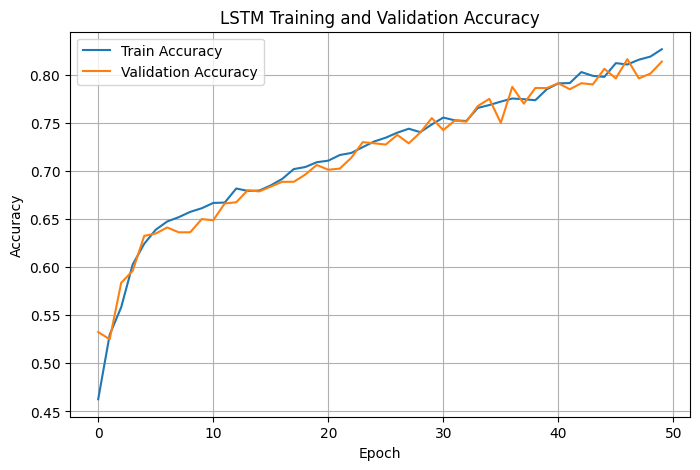

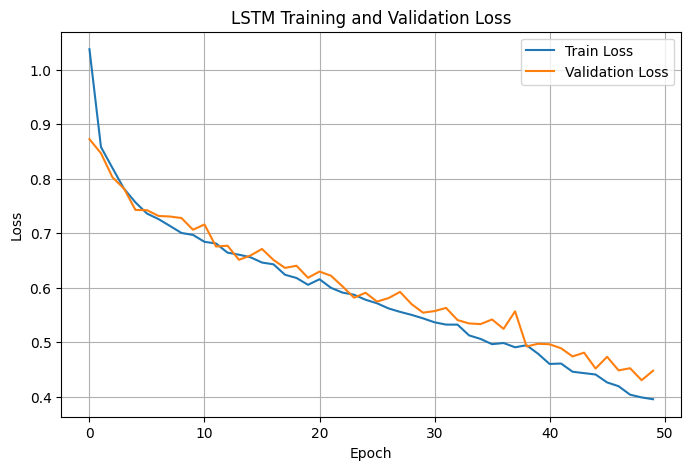

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

lstm_model = Sequential([
    Input(shape=(num_features, 1)),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history_lstm = lstm_model.fit(
    X_train_dl, y_train_cat,
    validation_data=(X_val_dl, y_val_cat),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

evaluate_model(lstm_model, X_test_dl, y_test, "LSTM")

# Plot Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(8, 5))
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# LSTM WITH BN

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.4636 - loss: 1.0487 - val_accuracy: 0.4863 - val_loss: 1.0574 - learning_rate: 0.0010
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5236 - loss: 0.9127 - val_accuracy: 0.5587 - val_loss: 0.8896 - learning_rate: 0.0010
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5450 - loss: 0.8665 - val_accuracy: 0.6288 - val_loss: 0.8190 - learning_rate: 0.0010
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5761 - loss: 0.8397 - val_accuracy: 0.6100 - val_loss: 0.7862 - learning_rate: 0.0010
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5946 - loss: 0.8084 - val_accuracy: 0.6250 - val_loss: 0.7539 - learning_rate: 0.0010
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6212 - loss: 0.7733 - val_accuracy: 0.4988 - val_loss: 1.1194 - learning_rate: 0.0010
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6368 - loss: 0.

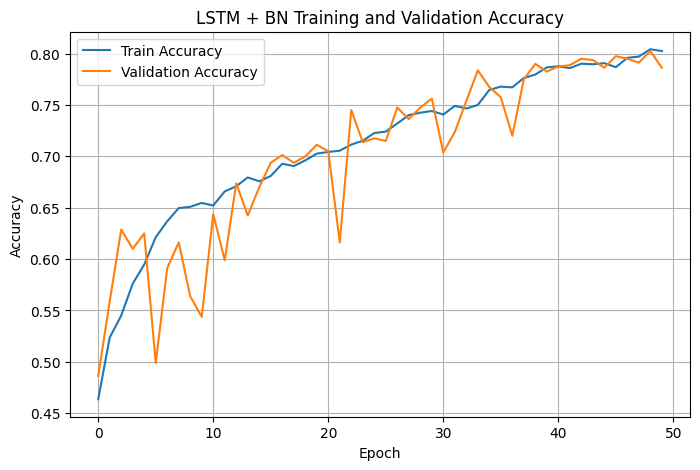

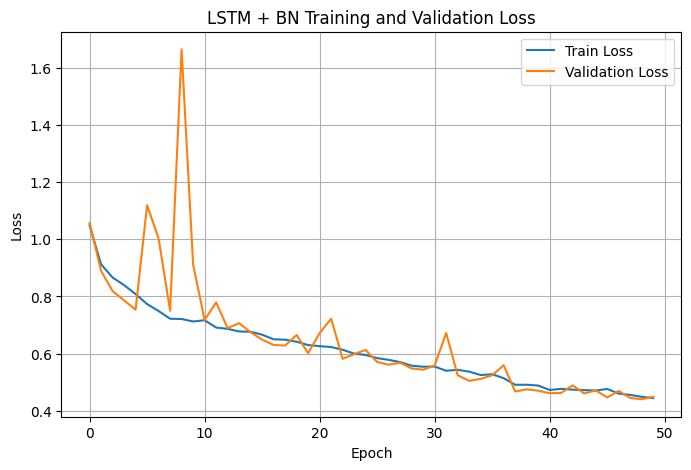

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

lstm_bn_model = Sequential([
    Input(shape=(num_features, 1)),
    LSTM(64, return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

lstm_bn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history_lstm_bn = lstm_bn_model.fit(
    X_train_dl, y_train_cat,
    validation_data=(X_val_dl, y_val_cat),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

evaluate_model(lstm_bn_model, X_test_dl, y_test, "LSTM + BN")

# Plot Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_lstm_bn.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm_bn.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM + BN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(8, 5))
plt.plot(history_lstm_bn.history['loss'], label='Train Loss')
plt.plot(history_lstm_bn.history['val_loss'], label='Validation Loss')
plt.title('LSTM + BN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# BILSTM WITH EARLY STOPPING

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.4734 - loss: 1.0036 - val_accuracy: 0.5325 - val_loss: 0.8509 - learning_rate: 0.0010
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5443 - loss: 0.8460 - val_accuracy: 0.5775 - val_loss: 0.8462 - learning_rate: 0.0010
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5752 - loss: 0.8078 - val_accuracy: 0.5788 - val_loss: 0.8032 - learning_rate: 0.0010
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6305 - loss: 0.7524 - val_accuracy: 0.6087 - val_loss: 0.7680 - learning_rate: 0.0010
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6423 - loss: 0.7306 - val_accuracy: 0.6438 - val_loss: 0.7203 - learning_rate: 0.0010
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6466 - loss: 0.7092 - val_accuracy: 0.6525 - val_loss: 0.7113 - learning_rate: 0.0010
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6573 - loss: 0.

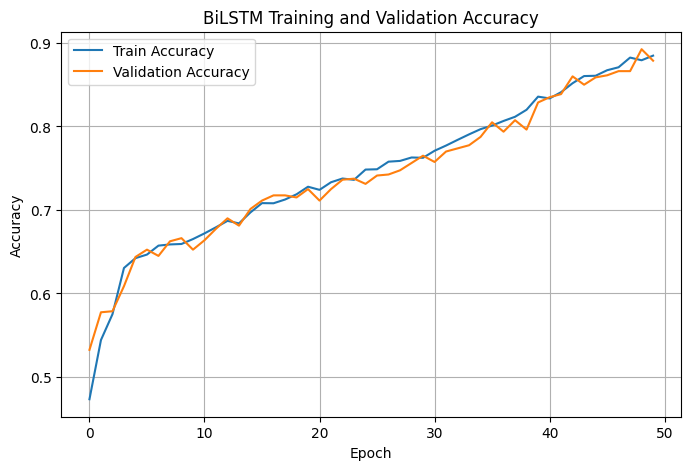

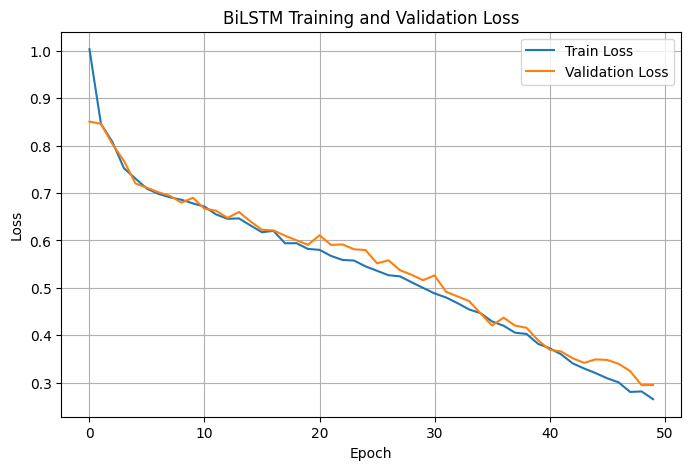

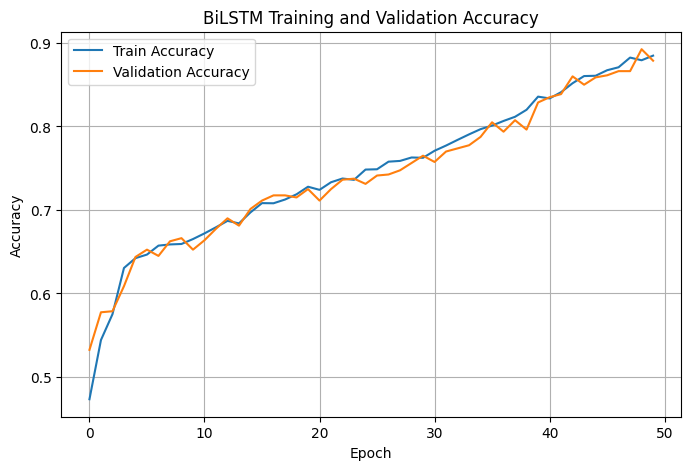

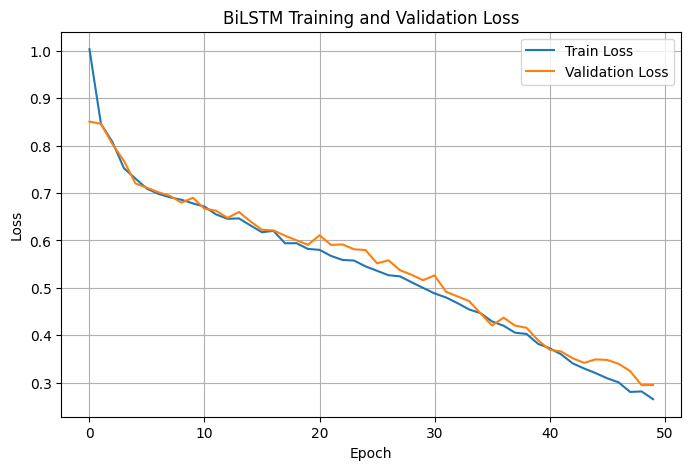

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

bilstm_model = Sequential([
    Input(shape=(num_features, 1)),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

bilstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history_bilstm = bilstm_model.fit(
    X_train_dl, y_train_cat,
    validation_data=(X_val_dl, y_val_cat),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

evaluate_model(bilstm_model, X_test_dl, y_test, "BiLSTM")

# Plot Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_bilstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_bilstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('BiLSTM Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(8, 5))
plt.plot(history_bilstm.history['loss'], label='Train Loss')
plt.plot(history_bilstm.history['val_loss'], label='Validation Loss')
plt.title('BiLSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
# Plot Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_bilstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_bilstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('BiLSTM Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(8, 5))
plt.plot(history_bilstm.history['loss'], label='Train Loss')
plt.plot(history_bilstm.history['val_loss'], label='Validation Loss')
plt.title('BiLSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 2. BiLSTM model with call back early stop and plateau

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.4804 - loss: 1.0059 - val_accuracy: 0.5312 - val_loss: 0.8454 - learning_rate: 0.0010
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.5282 - loss: 0.8576 - val_accuracy: 0.5750 - val_loss: 0.8149 - learning_rate: 0.0010
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.5707 - loss: 0.8120 - val_accuracy: 0.5700 - val_loss: 0.8014 - learning_rate: 0.0010
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5970 - loss: 0.7909 - val_accuracy: 0.5938 - val_loss: 0.7752 - learning_rate: 0.0010
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.6211 - loss: 0.7623 - val_accuracy: 0.5863 - val_loss: 0.7789 - learning_rate: 0.0010
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.6275 - loss: 0.7478 - val_accuracy: 0.6500 - val_loss: 0.7188 - learning_rate: 0.0010
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6527 - loss: 0

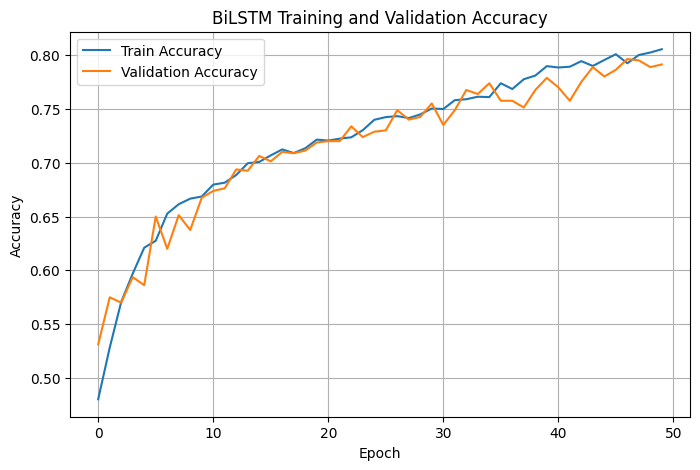

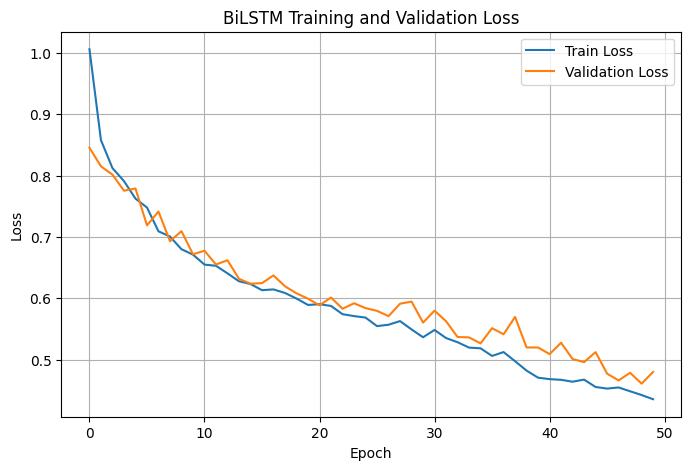

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

bilstm_model = Sequential([
    Input(shape=(num_features, 1)),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

bilstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history_bilstm = bilstm_model.fit(
    X_train_dl, y_train_cat,
    validation_data=(X_val_dl, y_val_cat),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

evaluate_model(bilstm_model, X_test_dl, y_test, "BiLSTM")

# Plot Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_bilstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_bilstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('BiLSTM Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(8, 5))
plt.plot(history_bilstm.history['loss'], label='Train Loss')
plt.plot(history_bilstm.history['val_loss'], label='Validation Loss')
plt.title('BiLSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# CNN model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

cnn_model = Sequential([
    Input(shape=(num_features, 1)),
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history_cnn = cnn_model.fit(
    X_train_dl, y_train_cat,
    validation_data=(X_val_dl, y_val_cat),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

evaluate_model(cnn_model, X_test_dl, y_test, "CNN")

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5652 - loss: 0.8822 - val_accuracy: 0.6862 - val_loss: 0.6822
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7143 - loss: 0.6263 - val_accuracy: 0.7763 - val_loss: 0.4964
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7613 - loss: 0.5244 - val_accuracy: 0.7812 - val_loss: 0.4763
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7995 - loss: 0.4643 - val_accuracy: 0.8100 - val_loss: 0.4301
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8055 - loss: 0.4426 - val_accuracy: 0.8213 - val_loss: 0.4256
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8205 - loss: 0.4104 - val_accuracy: 0.8413 - val_loss: 0.3823
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8359 - loss: 0.3929 - val_accuracy: 0.8462 - val_loss: 0.3622
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8432 - loss: 0.3743 - val_accuracy: 0

(0.949375,
 0.9497040270411268,
 0.949489483929714,
 array([2, 1, 0, ..., 3, 0, 2]))

# CNN-BiLSTM model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

cnn_bilstm_model = Sequential([
    Input(shape=(num_features, 1)),
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

cnn_bilstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history_cnn_bilstm = cnn_bilstm_model.fit(
    X_train_dl, y_train_cat,
    validation_data=(X_val_dl, y_val_cat),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

evaluate_model(cnn_bilstm_model, X_test_dl, y_test, "CNN BiLSTM")

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.5714 - loss: 0.8817 - val_accuracy: 0.6363 - val_loss: 0.7458
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.6320 - loss: 0.7427 - val_accuracy: 0.6375 - val_loss: 0.7342
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6407 - loss: 0.7283 - val_accuracy: 0.6513 - val_loss: 0.7227
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6511 - loss: 0.7092 - val_accuracy: 0.6538 - val_loss: 0.7023
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6498 - loss: 0.7018 - val_accuracy: 0.6587 - val_loss: 0.7004
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6604 - loss: 0.6921 - val_accuracy: 0.6687 - val_loss: 0.6887
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6720 - loss: 0.6607 - val_accuracy: 0.7038 - val_loss: 0.6034
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7275 - loss: 0.5767 - val_acc

(0.9175,
 0.9202068413490366,
 0.9182013100675139,
 array([2, 1, 0, ..., 3, 0, 3]))

# bilstm plotting and batch normalization

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization

all_results = []
all_histories = {}

def evaluate_model(model, X_eval, y_true, model_name="Model"):
    y_prob = model.predict(X_eval, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n{model_name} Results")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("F1-score :", round(f1, 4))
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, zero_division=0))

    all_results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "F1_score": f1
    })

    return y_pred

def plot_training_history(history, model_name):
    plt.figure(figsize=(7, 5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_conf_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    plt.figure(figsize=(6, 6))
    disp.plot()
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.4604 - loss: 1.0926 - val_accuracy: 0.4663 - val_loss: 1.0950
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5354 - loss: 0.9010 - val_accuracy: 0.4950 - val_loss: 1.1398
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5682 - loss: 0.8577 - val_accuracy: 0.5263 - val_loss: 0.8734
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5930 - loss: 0.8161 - val_accuracy: 0.4900 - val_loss: 1.1426
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6061 - loss: 0.7989 - val_accuracy: 0.4963 - val_loss: 1.0470
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6245 - loss: 0.7630 - val_accuracy: 0.5875 - val_loss: 1.0065
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6377 - loss: 0.7434 - val_accuracy: 0.6425 - val_loss: 0.7254
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6445 - loss: 0.7306 - val_accu

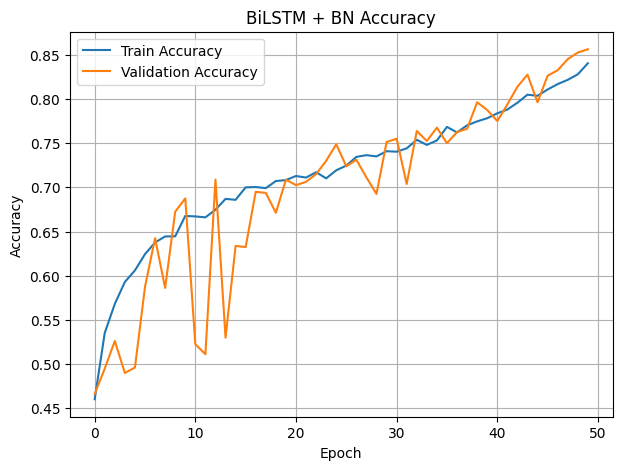

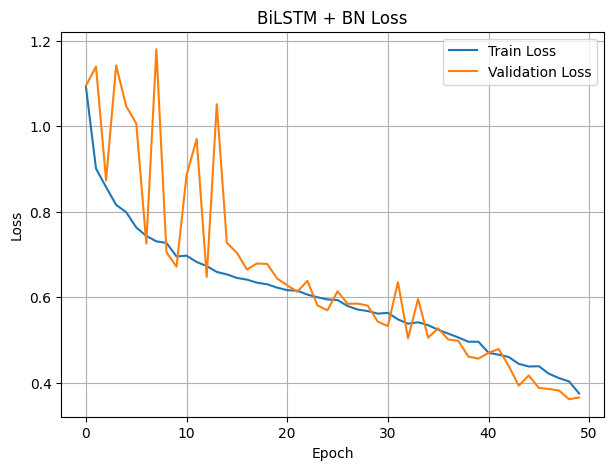

<Figure size 600x600 with 0 Axes>

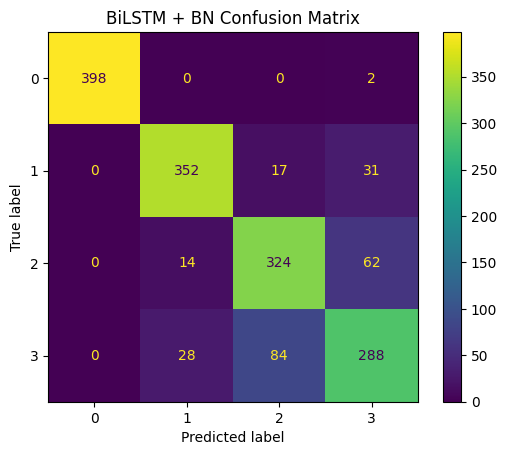

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout, BatchNormalization

bilstm_bn_model = Sequential([
    Input(shape=(num_features, 1)),
    Bidirectional(LSTM(64, return_sequences=False)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')
])

bilstm_bn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history_bilstm_bn = bilstm_bn_model.fit(
    X_train_dl, y_train_cat,
    validation_data=(X_val_dl, y_val_cat),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

all_histories["BiLSTM + BN"] = history_bilstm_bn
y_pred_bilstm_bn = evaluate_model(bilstm_bn_model, X_test_dl, y_test, "BiLSTM + BN")
plot_training_history(history_bilstm_bn, "BiLSTM + BN")
plot_conf_matrix(y_test, y_pred_bilstm_bn, "BiLSTM + BN")

# CNN WITH Batch normalization

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.6363 - loss: 0.8334 - val_accuracy: 0.5450 - val_loss: 1.0278
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7293 - loss: 0.6155 - val_accuracy: 0.5975 - val_loss: 0.7366
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7680 - loss: 0.5390 - val_accuracy: 0.8112 - val_loss: 0.4460
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7918 - loss: 0.4815 - val_accuracy: 0.8288 - val_loss: 0.3814
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8127 - loss: 0.4401 - val_accuracy: 0.8637 - val_loss: 0.3470
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8286 - loss: 0.4237 - val_accuracy: 0.8775 - val_loss: 0.3259
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8252 - loss: 0.4224 - val_accuracy: 0.8825 - val_loss: 0.3200
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8371 - loss: 0.3908 - val_accuracy: 0

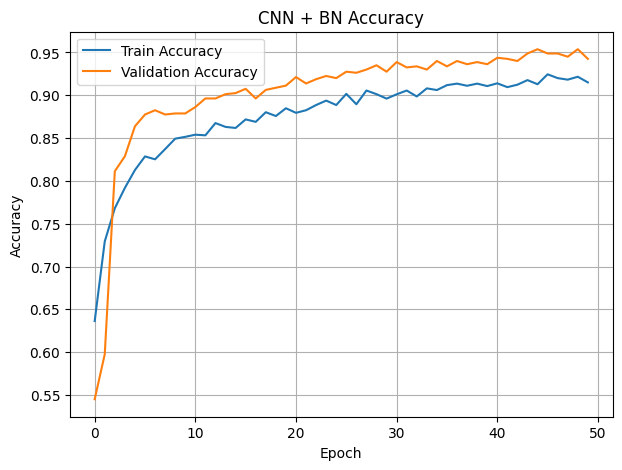

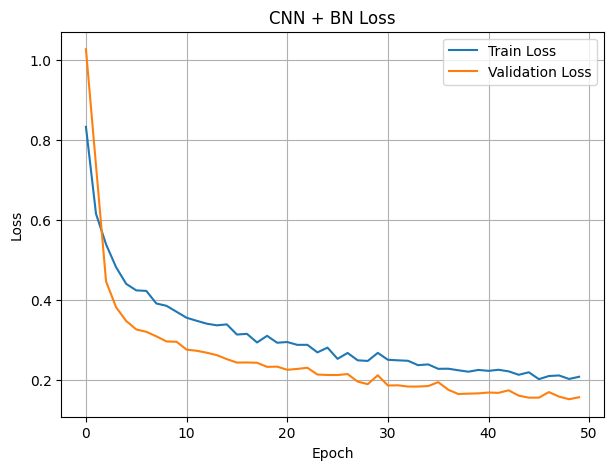

<Figure size 600x600 with 0 Axes>

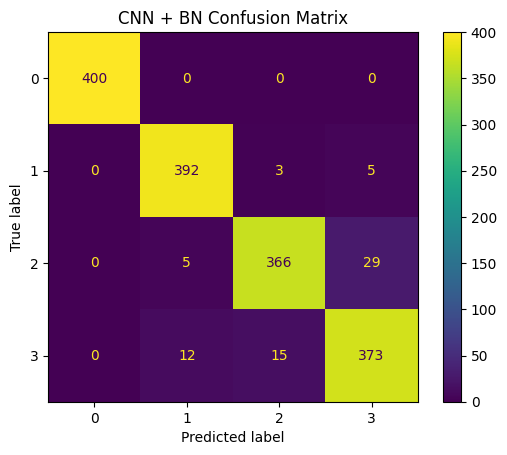

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization

cnn_bn_model = Sequential([
    Input(shape=(num_features, 1)),

    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Flatten(),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

cnn_bn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history_cnn_bn = cnn_bn_model.fit(
    X_train_dl, y_train_cat,
    validation_data=(X_val_dl, y_val_cat),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

all_histories["CNN + BN"] = history_cnn_bn
y_pred_cnn_bn = evaluate_model(cnn_bn_model, X_test_dl, y_test, "CNN + BN")
plot_training_history(history_cnn_bn, "CNN + BN")
plot_conf_matrix(y_test, y_pred_cnn_bn, "CNN + BN")

# IMPROVED MODEL (Drop-in replacement)

Epoch 1/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.6620 - loss: 0.7578 - val_accuracy: 0.4975 - val_loss: 1.0149 - learning_rate: 0.0010
Epoch 2/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.7675 - loss: 0.5411 - val_accuracy: 0.5738 - val_loss: 0.7711 - learning_rate: 0.0010
Epoch 3/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.8087 - loss: 0.4517 - val_accuracy: 0.8413 - val_loss: 0.4022 - learning_rate: 0.0010
Epoch 4/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.8229 - loss: 0.4237 - val_accuracy: 0.8687 - val_loss: 0.3188 - learning_rate: 0.0010
Epoch 5/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.8325 - loss: 0.4055 - val_accuracy: 0.8675 - val_loss: 0.3258 - learning_rate: 0.0010
Epoch 6/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.8516 - loss: 0.3616 - val_accuracy: 0.8938 - val_loss: 0.2653 - learning_rate: 0.0010
Epoch 7/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.8645 - loss: 0

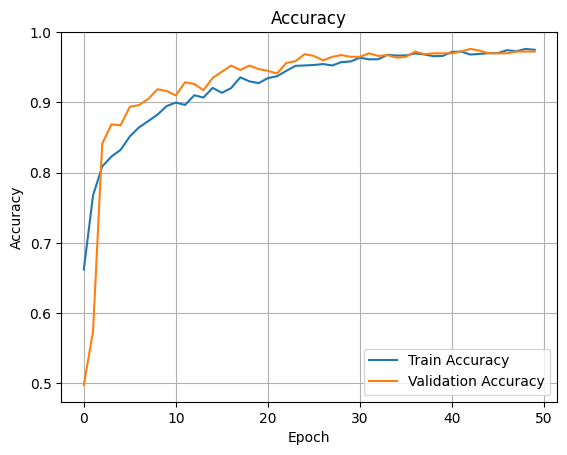

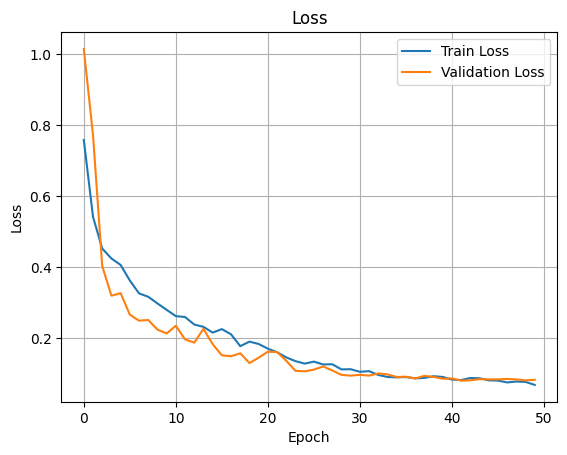

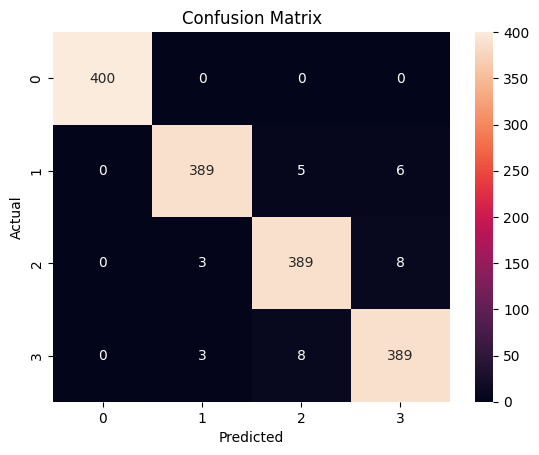

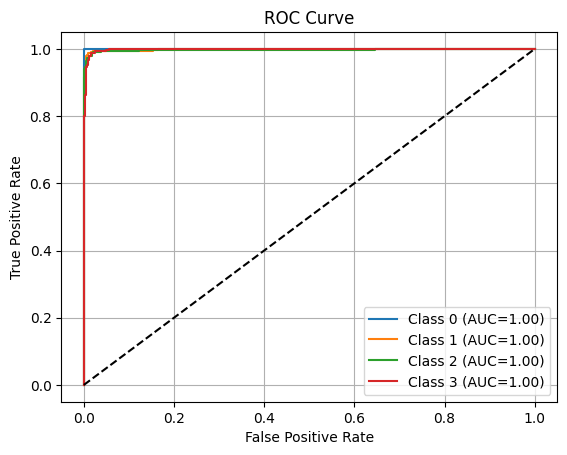

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

cnn_bn_model = Sequential([
    Input(shape=(num_features, 1)),

    # Block 1
    Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.2),

    # Block 2
    Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.25),

    # NEW Block 3 (important)
    Conv1D(256, kernel_size=5, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    # Replace Flatten
    GlobalAveragePooling1D(),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

cnn_bn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history_cnn_bn = cnn_bn_model.fit(
    X_train_dl, y_train_cat,
    validation_data=(X_val_dl, y_val_cat),
    epochs=60,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
# =========================
# 4. PREDICTIONS
# =========================
y_pred_probs = cnn_bn_model.predict(X_test_dl)
y_pred = np.argmax(y_pred_probs, axis=1)

# =========================
# 5. TRAINING CURVES
# =========================
plt.figure()
plt.plot(history_cnn_bn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn_bn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(history_cnn_bn.history['loss'], label='Train Loss')
plt.plot(history_cnn_bn.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# =========================
# 6. CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# =========================
# 7. ROC CURVE (MULTICLASS)
# =========================
y_test_bin = label_binarize(y_test, classes=list(range(num_classes)))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC={roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

# Train-test contamination (duplicate samples)

In [ ]:
import numpy as np

print("Train-Test overlap:",
      len(set(map(tuple, X_train.reshape(len(X_train), -1)))) &
      len(set(map(tuple, X_test.reshape(len(X_test), -1)))))

Train-Test overlap: 1088


# synthetic separation

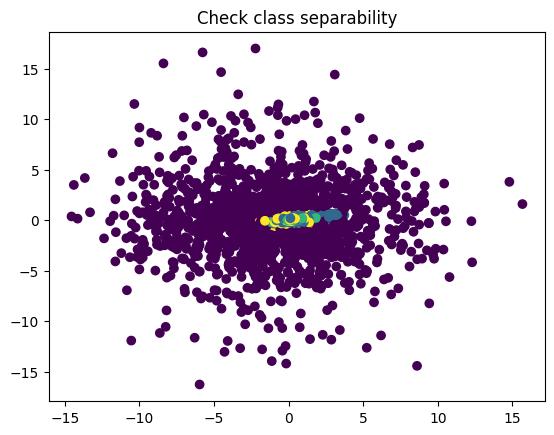

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_flat = X_train.reshape(len(X_train), -1)
X_pca = PCA(n_components=2).fit_transform(X_flat)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train)
plt.title("Check class separability")
plt.show()

In [ ]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train labels distribution:", np.bincount(y_train))
print("Test labels distribution:", np.bincount(y_test))

Train shape: (5600, 16)
Test shape: (1600, 16)
Train labels distribution: [1400 1400 1400 1400]
Test labels distribution: [400 400 400 400]


In [ ]:
print(history_cnn_bn.history['accuracy'][-1])
print(history_cnn_bn.history['val_accuracy'][-1])

0.9750000238418579
0.9725000262260437


# PARAMETER OPTI FROM CLAUDE

Model: "Optimized_CNN_BN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_22 (Conv1D)              │ (None, 16, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 16, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 16, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 16, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_18 (MaxPooling1D) │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_24 (Conv1D)              │ (None, 8, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 8, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 8, 256)         │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 8, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_19 (MaxPooling1D) │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_26 (Conv1D)              │ (None, 4, 512)         │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 4, 512)         │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_20 (MaxPooling1D) │ (None, 2, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 2, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_6      │ (None, 512)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 910,340 (3.47 MB)

 Trainable params: 907,012 (3.46 MB)

 Non-trainable params: 3,328 (13.00 KB)

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 29s 173ms/step - accuracy: 0.6623 - loss: 0.9944 - val_accuracy: 0.2500 - val_loss: 1.3850 - learning_rate: 0.0010
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 161ms/step - accuracy: 0.7904 - loss: 0.7463 - val_accuracy: 0.2500 - val_loss: 2.5108 - learning_rate: 0.0010
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 162ms/step - accuracy: 0.8296 - loss: 0.6823 - val_accuracy: 0.2512 - val_loss: 3.0162 - learning_rate: 0.0010
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 163ms/step - accuracy: 0.8604 - loss: 0.6281 - val_accuracy: 0.2575 - val_loss: 3.3306 - learning_rate: 0.0010
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.8844 - loss: 0.5941
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 158ms/step - accuracy: 0.8813 - loss: 0.5988 - val_accuracy: 0.4162 - val_loss: 1.4324 - learning_rate: 0.0010
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 163ms/step - accuracy: 0.9043 - loss: 0.55

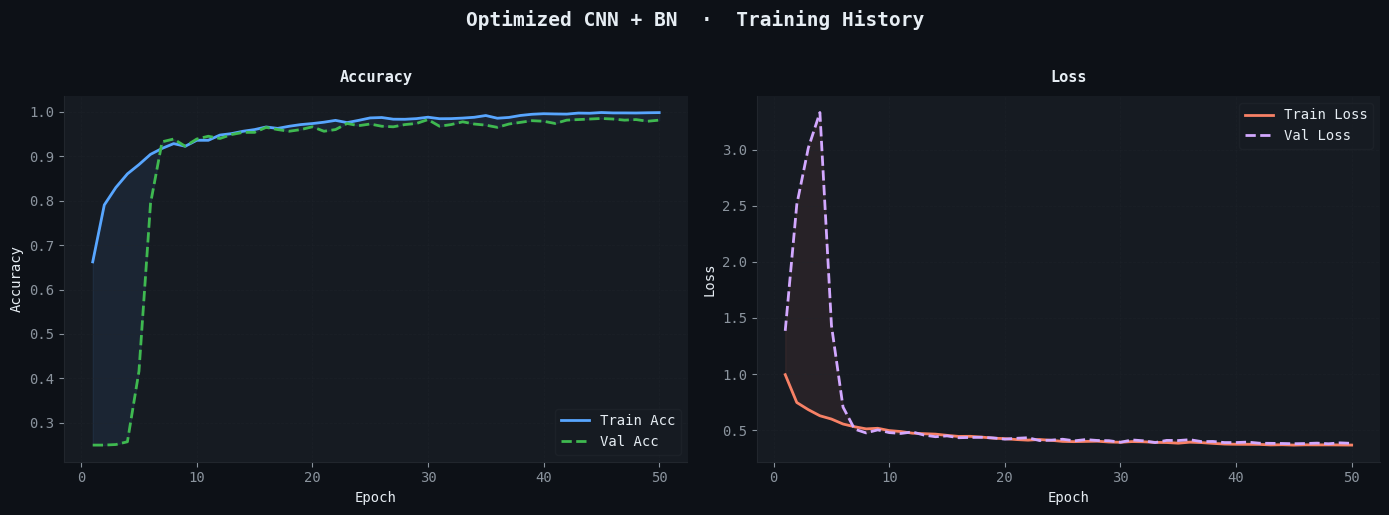

✔  Saved: training_history.png


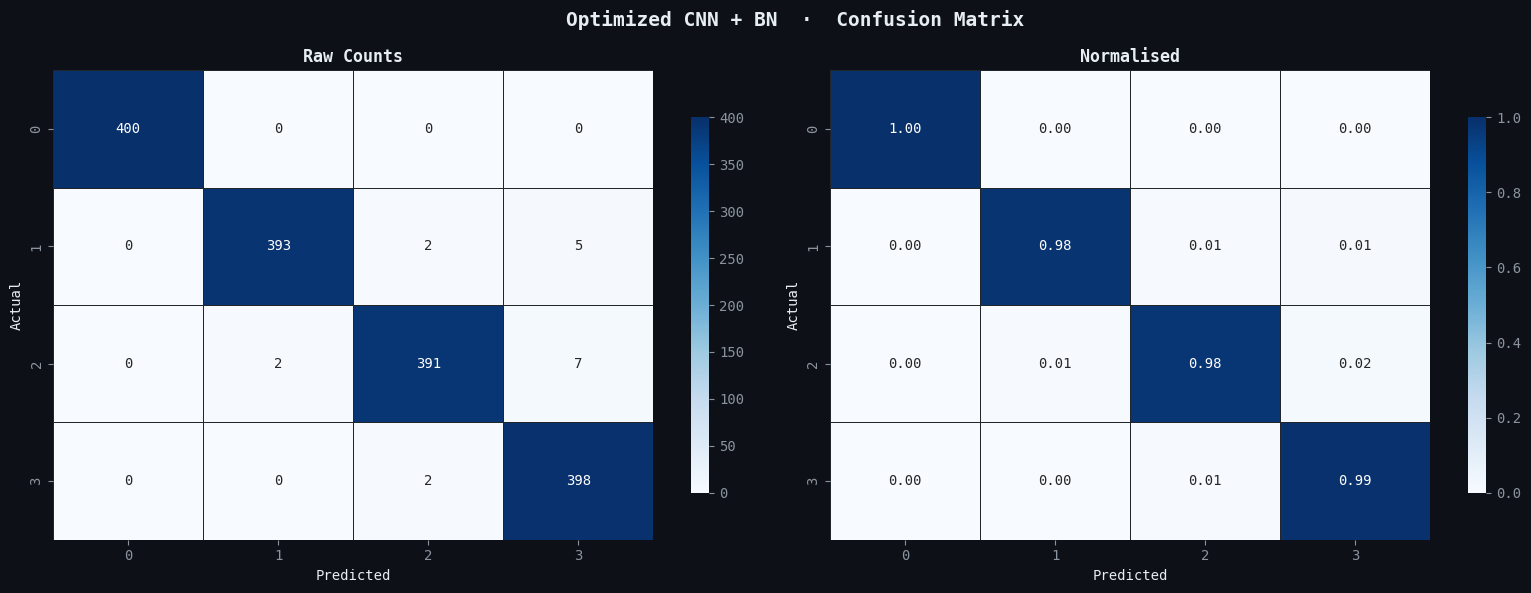

✔  Saved: confusion_matrix.png


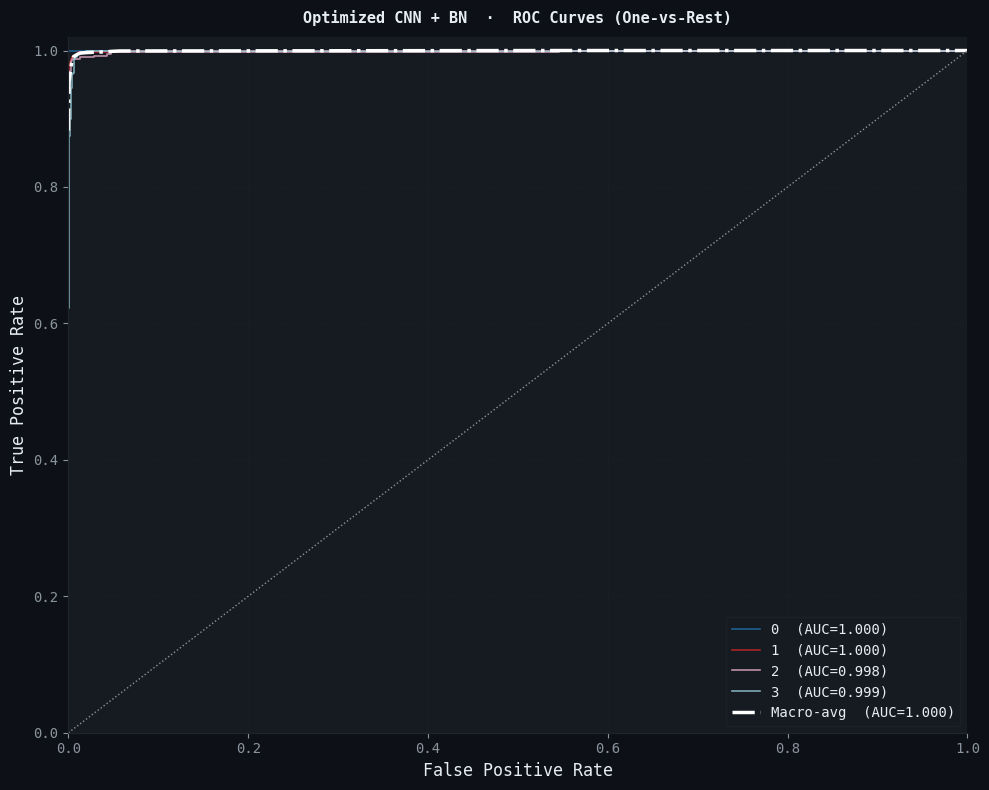

✔  Saved: roc_curves.png


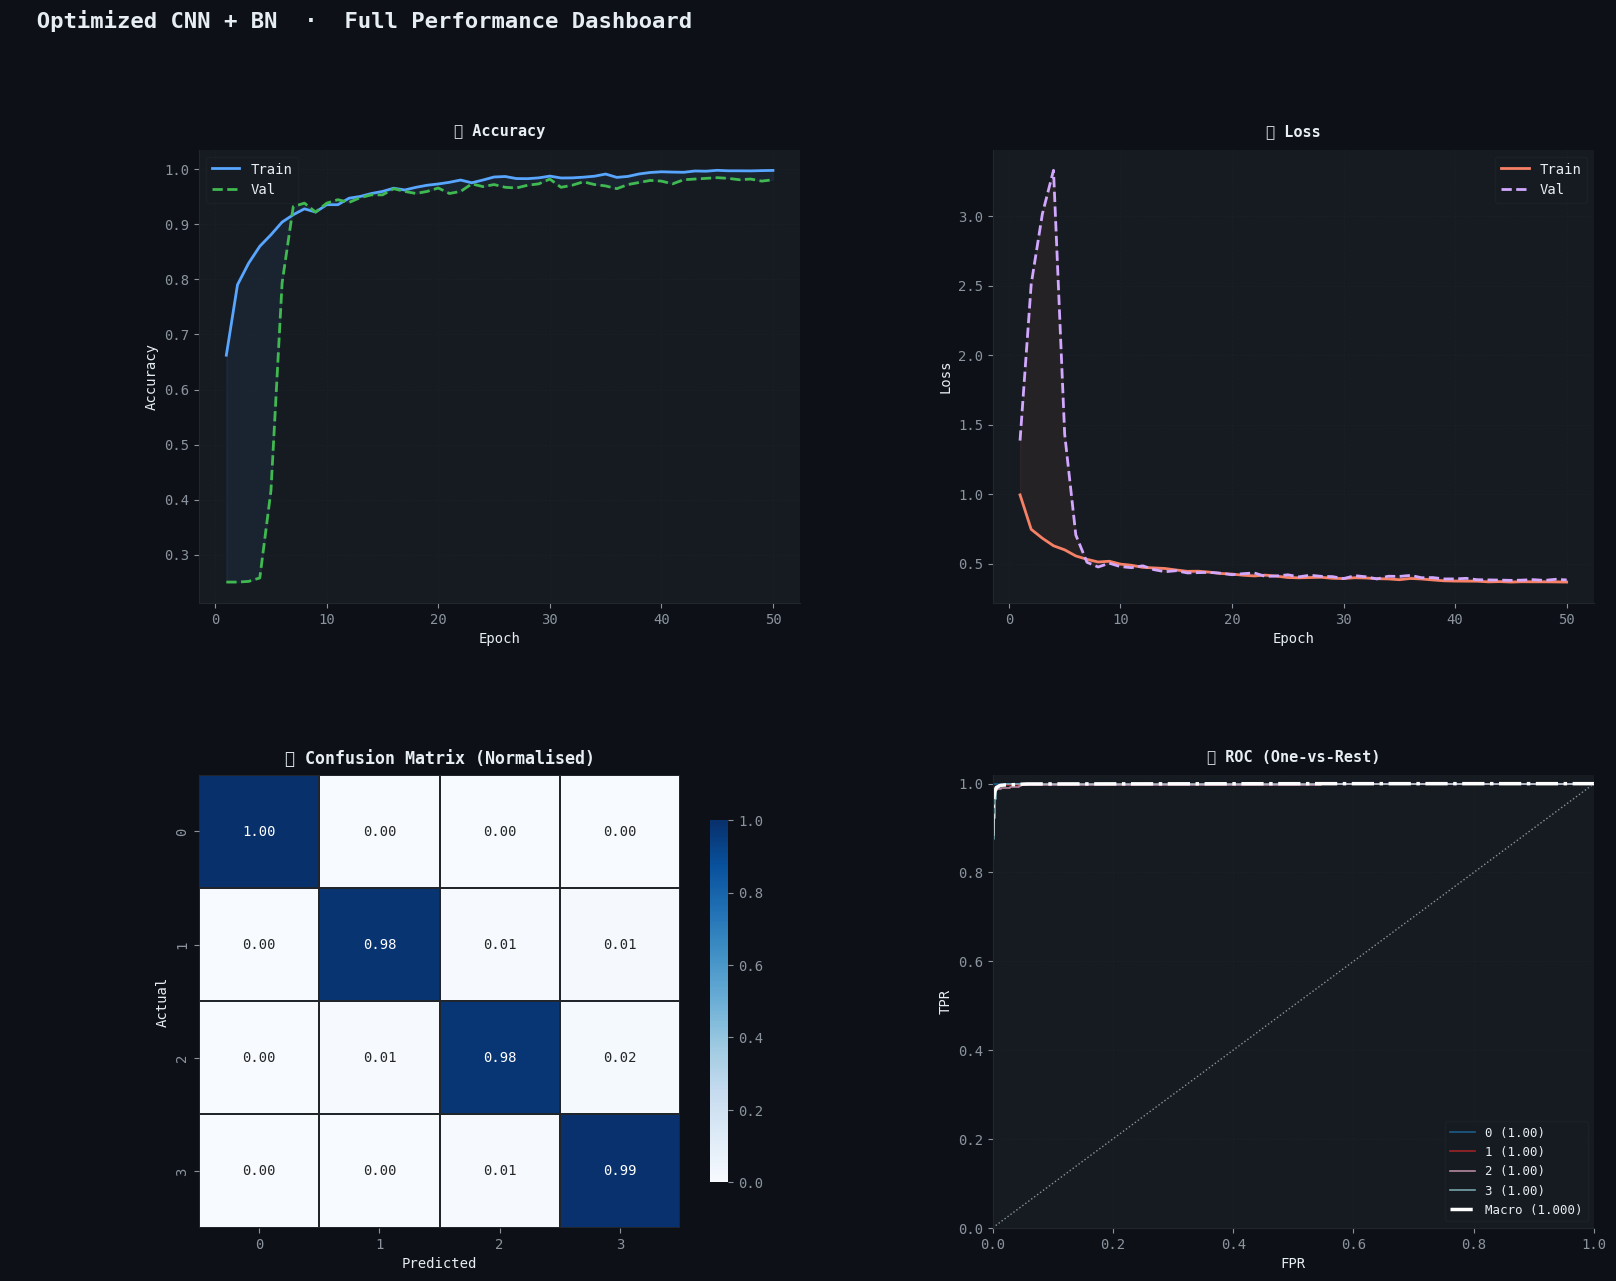

✔  Saved: dashboard.png

──────────────────────────────────────────────────
  Optimized CNN + BN
  Test Loss     : 0.3746
  Test Accuracy : 0.9887
──────────────────────────────────────────────────
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.99      0.98      0.99       400
           2       0.99      0.98      0.98       400
           3       0.97      0.99      0.98       400

    accuracy                           0.99      1600
   macro avg       0.99      0.99      0.99      1600
weighted avg       0.99      0.99      0.99      1600

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


array([2, 3, 0, ..., 2, 0, 2])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, GlobalAveragePooling1D,
    Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# ─────────────────────────────────────────────────────────────────────────────
# STYLE CONFIG  (change to taste)
# ─────────────────────────────────────────────────────────────────────────────
STYLE = {
    "bg":        "#0D1117",
    "panel":     "#161B22",
    "accent1":   "#58A6FF",   # blue
    "accent2":   "#3FB950",   # green
    "accent3":   "#F78166",   # red/orange
    "accent4":   "#D2A8FF",   # purple
    "text":      "#E6EDF3",
    "subtext":   "#8B949E",
    "grid":      "#21262D",
}

plt.rcParams.update({
    "figure.facecolor":  STYLE["bg"],
    "axes.facecolor":    STYLE["panel"],
    "axes.edgecolor":    STYLE["grid"],
    "axes.labelcolor":   STYLE["text"],
    "xtick.color":       STYLE["subtext"],
    "ytick.color":       STYLE["subtext"],
    "text.color":        STYLE["text"],
    "grid.color":        STYLE["grid"],
    "grid.linestyle":    "--",
    "grid.linewidth":    0.6,
    "font.family":       "monospace",
    "legend.facecolor":  STYLE["panel"],
    "legend.edgecolor":  STYLE["grid"],
})


# ─────────────────────────────────────────────────────────────────────────────
# ASSUME THESE VARIABLES EXIST IN YOUR ENVIRONMENT:
#   num_features, num_classes
#   X_train_dl, y_train_cat  (numpy arrays)
#   X_val_dl,   y_val_cat
#   X_test_dl,  y_test        (y_test: integer class labels, NOT one-hot)
#   class_names               (list of str, optional)
# ─────────────────────────────────────────────────────────────────────────────


# ─────────────────────────────────────────────────────────────────────────────
# 1.  MODEL DEFINITION
# ─────────────────────────────────────────────────────────────────────────────
def build_optimized_cnn(num_features, num_classes):
    model = Sequential([
        Input(shape=(num_features, 1)),

        # ── Block 1 ──────────────────────────────────────────────
        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        # ── Block 2 ──────────────────────────────────────────────
        Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        # ── Block 3 ──────────────────────────────────────────────
        Conv1D(512, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        # ── Head ─────────────────────────────────────────────────
        GlobalAveragePooling1D(),          # fewer params vs Flatten
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(num_classes, activation='softmax'),
    ], name="Optimized_CNN_BN")

    model.compile(
        optimizer=AdamW(learning_rate=0.001, weight_decay=1e-4),
        loss=CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy'],
    )
    return model


# ─────────────────────────────────────────────────────────────────────────────
# 2.  CALLBACKS
# ─────────────────────────────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1,
)


# ─────────────────────────────────────────────────────────────────────────────
# 3.  TRAIN
# ─────────────────────────────────────────────────────────────────────────────
cnn_bn_model = build_optimized_cnn(num_features, num_classes)
cnn_bn_model.summary()

history_cnn_bn = cnn_bn_model.fit(
    X_train_dl, y_train_cat,
    validation_data=(X_val_dl, y_val_cat),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)


# ─────────────────────────────────────────────────────────────────────────────
# 4.  PREDICTIONS
# ─────────────────────────────────────────────────────────────────────────────
y_pred_prob  = cnn_bn_model.predict(X_test_dl)          # shape (N, num_classes)
y_pred_label = np.argmax(y_pred_prob, axis=1)           # integer predictions

# Optional: if y_test is one-hot encoded, convert it
if y_test.ndim > 1:
    y_test_int = np.argmax(y_test, axis=1)
else:
    y_test_int = y_test.copy()

# class_names fallback
try:
    class_names
except NameError:
    class_names = [str(i) for i in range(num_classes)]


# ─────────────────────────────────────────────────────────────────────────────
# 5.  PLOTTING HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def _panel(ax, title):
    ax.set_title(title, fontsize=11, fontweight="bold",
                 color=STYLE["text"], pad=10)
    ax.grid(True, alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)


# ── 5-A  Training curves (accuracy + loss) ───────────────────────────────────
def plot_training_history(history, model_name="Model"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor(STYLE["bg"])
    fig.suptitle(f"{model_name}  ·  Training History",
                 fontsize=14, fontweight="bold", color=STYLE["text"], y=1.02)

    epochs = range(1, len(history.history['accuracy']) + 1)

    # Accuracy
    ax = axes[0]
    ax.plot(epochs, history.history['accuracy'],
            color=STYLE["accent1"], lw=2, label='Train Acc')
    ax.plot(epochs, history.history['val_accuracy'],
            color=STYLE["accent2"], lw=2, linestyle='--', label='Val Acc')
    ax.fill_between(epochs, history.history['accuracy'],
                    history.history['val_accuracy'],
                    alpha=0.08, color=STYLE["accent1"])
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
    ax.legend(framealpha=0.6)
    _panel(ax, "Accuracy")

    # Loss
    ax = axes[1]
    ax.plot(epochs, history.history['loss'],
            color=STYLE["accent3"], lw=2, label='Train Loss')
    ax.plot(epochs, history.history['val_loss'],
            color=STYLE["accent4"], lw=2, linestyle='--', label='Val Loss')
    ax.fill_between(epochs, history.history['loss'],
                    history.history['val_loss'],
                    alpha=0.08, color=STYLE["accent3"])
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(framealpha=0.6)
    _panel(ax, "Loss")

    plt.tight_layout()
    plt.savefig("training_history.png", dpi=150, bbox_inches='tight',
                facecolor=STYLE["bg"])
    plt.show()
    print("✔  Saved: training_history.png")


# ── 5-B  Confusion matrix ─────────────────────────────────────────────────────
def plot_conf_matrix(y_true, y_pred, model_name="Model"):
    cm   = confusion_matrix(y_true, y_pred)
    norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)   # row-normalized

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor(STYLE["bg"])
    fig.suptitle(f"{model_name}  ·  Confusion Matrix",
                 fontsize=14, fontweight="bold", color=STYLE["text"])

    for ax, data, title, fmt in zip(
        axes,
        [cm,   norm],
        ["Raw Counts", "Normalised"],
        ["d",  ".2f"],
    ):
        sns.heatmap(
            data, annot=True, fmt=fmt,
            xticklabels=class_names, yticklabels=class_names,
            cmap="Blues", linewidths=0.4, linecolor=STYLE["grid"],
            ax=ax, cbar_kws={"shrink": 0.8},
        )
        ax.set_xlabel("Predicted", color=STYLE["text"])
        ax.set_ylabel("Actual",    color=STYLE["text"])
        ax.set_title(title, color=STYLE["text"], fontweight="bold")
        ax.tick_params(colors=STYLE["subtext"])

    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight',
                facecolor=STYLE["bg"])
    plt.show()
    print("✔  Saved: confusion_matrix.png")


# ── 5-C  ROC curves ───────────────────────────────────────────────────────────
def plot_roc_curves(y_true_int, y_prob, model_name="Model"):
    """
    Plots per-class ROC + macro-average ROC.
    y_true_int : 1-D integer labels
    y_prob     : (N, num_classes) probability array
    """
    n_classes = y_prob.shape[1]
    y_bin     = label_binarize(y_true_int, classes=list(range(n_classes)))

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Macro average
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(all_fpr, mean_tpr)

    # ── Plot ──────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 8))
    fig.patch.set_facecolor(STYLE["bg"])

    # Per-class lines (thin, coloured)
    palette = plt.cm.get_cmap("tab20", n_classes)
    for i in range(n_classes):
        ax.plot(fpr[i], tpr[i], lw=1.2, alpha=0.75,
                color=palette(i),
                label=f"{class_names[i]}  (AUC={roc_auc[i]:.3f})")

    # Macro average (thick white)
    ax.plot(fpr["macro"], tpr["macro"],
            color="white", lw=2.5, linestyle="-.",
            label=f"Macro-avg  (AUC={roc_auc['macro']:.3f})")

    # Diagonal
    ax.plot([0, 1], [0, 1], color=STYLE["subtext"],
            lw=1, linestyle=":")

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate",  fontsize=12)
    _panel(ax, f"{model_name}  ·  ROC Curves (One-vs-Rest)")
    ax.legend(loc="lower right", fontsize=8 if n_classes > 6 else 10,
              framealpha=0.5)

    plt.tight_layout()
    plt.savefig("roc_curves.png", dpi=150, bbox_inches='tight',
                facecolor=STYLE["bg"])
    plt.show()
    print("✔  Saved: roc_curves.png")


# ── 5-D  Combined dashboard ──────────────────────────────────────────────────
def plot_dashboard(history, y_true_int, y_pred_int, y_prob, model_name="Model"):
    """Single figure with all four panels."""
    fig = plt.figure(figsize=(18, 14))
    fig.patch.set_facecolor(STYLE["bg"])
    fig.suptitle(f"  {model_name}  ·  Full Performance Dashboard",
                 fontsize=16, fontweight="bold",
                 color=STYLE["text"], x=0.02, ha="left")

    gs = gridspec.GridSpec(2, 2, figure=fig,
                           hspace=0.38, wspace=0.32)

    epochs = range(1, len(history.history['accuracy']) + 1)

    # ── Accuracy ──────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(epochs, history.history['accuracy'],
             color=STYLE["accent1"], lw=2, label='Train')
    ax1.plot(epochs, history.history['val_accuracy'],
             color=STYLE["accent2"], lw=2, ls='--', label='Val')
    ax1.fill_between(epochs,
                     history.history['accuracy'],
                     history.history['val_accuracy'],
                     alpha=0.07, color=STYLE["accent1"])
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
    ax1.legend(framealpha=0.5)
    _panel(ax1, "① Accuracy")

    # ── Loss ──────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(epochs, history.history['loss'],
             color=STYLE["accent3"], lw=2, label='Train')
    ax2.plot(epochs, history.history['val_loss'],
             color=STYLE["accent4"], lw=2, ls='--', label='Val')
    ax2.fill_between(epochs,
                     history.history['loss'],
                     history.history['val_loss'],
                     alpha=0.07, color=STYLE["accent3"])
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
    ax2.legend(framealpha=0.5)
    _panel(ax2, "② Loss")

    # ── Confusion matrix ──────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    cm   = confusion_matrix(y_true_int, y_pred_int)
    norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(norm, annot=True, fmt=".2f",
                xticklabels=class_names,
                yticklabels=class_names,
                cmap="Blues", linewidths=0.3,
                linecolor=STYLE["grid"], ax=ax3,
                cbar_kws={"shrink": 0.8})
    ax3.set_xlabel("Predicted"); ax3.set_ylabel("Actual")
    ax3.set_title("③ Confusion Matrix (Normalised)",
                  color=STYLE["text"], fontweight="bold", pad=8)

    # ── ROC ───────────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    n_classes = y_prob.shape[1]
    y_bin     = label_binarize(y_true_int, classes=list(range(n_classes)))

    fpr_all, tpr_all, auc_all = {}, {}, {}
    for i in range(n_classes):
        fpr_all[i], tpr_all[i], _ = roc_curve(y_bin[:, i], y_prob[:, i])
        auc_all[i] = auc(fpr_all[i], tpr_all[i])

    all_fpr  = np.unique(np.concatenate([fpr_all[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_all[i], tpr_all[i])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    palette = plt.cm.get_cmap("tab20", n_classes)
    for i in range(n_classes):
        ax4.plot(fpr_all[i], tpr_all[i], lw=1.2,
                 alpha=0.7, color=palette(i),
                 label=f"{class_names[i]} ({auc_all[i]:.2f})")
    ax4.plot(all_fpr, mean_tpr, color="white", lw=2.5,
             ls="-.", label=f"Macro ({macro_auc:.3f})")
    ax4.plot([0, 1], [0, 1], color=STYLE["subtext"], lw=1, ls=":")
    ax4.set_xlim([0, 1]); ax4.set_ylim([0, 1.02])
    ax4.set_xlabel("FPR"); ax4.set_ylabel("TPR")
    ax4.legend(loc="lower right", fontsize=7 if n_classes > 5 else 9,
               framealpha=0.5)
    _panel(ax4, "④ ROC (One-vs-Rest)")

    plt.savefig("dashboard.png", dpi=150, bbox_inches='tight',
                facecolor=STYLE["bg"])
    plt.show()
    print("✔  Saved: dashboard.png")


# ─────────────────────────────────────────────────────────────────────────────
# 6.  EVALUATION HELPER
# ─────────────────────────────────────────────────────────────────────────────
def evaluate_model(model, X_test, y_true_int, model_name="Model"):
    loss, acc = model.evaluate(X_test, to_categorical(y_true_int), verbose=0)
    print(f"\n{'─'*50}")
    print(f"  {model_name}")
    print(f"  Test Loss     : {loss:.4f}")
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"{'─'*50}")
    print(classification_report(
        y_true_int,
        np.argmax(model.predict(X_test), axis=1),
        target_names=class_names,
    ))
    return np.argmax(model.predict(X_test), axis=1)


# ─────────────────────────────────────────────────────────────────────────────
# 7.  RUN ALL PLOTS
# ─────────────────────────────────────────────────────────────────────────────
# Individual plots
plot_training_history(history_cnn_bn, "Optimized CNN + BN")
plot_conf_matrix(y_test_int, y_pred_label, "Optimized CNN + BN")
plot_roc_curves(y_test_int, y_pred_prob,   "Optimized CNN + BN")

# Combined dashboard (all 4 in one figure)
plot_dashboard(
    history   = history_cnn_bn,
    y_true_int= y_test_int,
    y_pred_int= y_pred_label,
    y_prob    = y_pred_prob,
    model_name= "Optimized CNN + BN",
)

# Full evaluation report
evaluate_model(cnn_bn_model, X_test_dl, y_test_int, "Optimized CNN + BN")

# addressing spike

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, GlobalAveragePooling1D,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical


# ─────────────────────────────────────────────────────────────────────────────
# STYLE CONFIG  —  Clean White Dashboard
# ─────────────────────────────────────────────────────────────────────────────
STYLE = {
    "bg":       "#FFFFFF",
    "panel":    "#F7F9FC",
    "border":   "#DDE3ED",
    "accent1":  "#2563EB",   # blue       — train accuracy / train loss
    "accent2":  "#16A34A",   # green      — val accuracy
    "accent3":  "#DC2626",   # red        — val loss
    "accent4":  "#7C3AED",   # purple     — macro ROC
    "fill1":    "#DBEAFE",   # light blue fill
    "fill2":    "#DCFCE7",   # light green fill
    "text":     "#111827",
    "subtext":  "#6B7280",
    "grid":     "#E5E7EB",
}

plt.rcParams.update({
    "figure.facecolor":   STYLE["bg"],
    "axes.facecolor":     STYLE["panel"],
    "axes.edgecolor":     STYLE["border"],
    "axes.labelcolor":    STYLE["text"],
    "xtick.color":        STYLE["subtext"],
    "ytick.color":        STYLE["subtext"],
    "text.color":         STYLE["text"],
    "grid.color":         STYLE["grid"],
    "grid.linestyle":     "--",
    "grid.linewidth":     0.7,
    "font.family":        "DejaVu Sans",
    "legend.facecolor":   STYLE["bg"],
    "legend.edgecolor":   STYLE["border"],
    "legend.framealpha":  1.0,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
})


# ─────────────────────────────────────────────────────────────────────────────
# ASSUME THESE VARIABLES EXIST IN YOUR ENVIRONMENT:
#   num_features, num_classes
#   X_train_dl, y_train_cat   (numpy arrays)
#   X_val_dl,   y_val_cat
#   X_test_dl,  y_test         (y_test: integer class labels, NOT one-hot)
#   class_names                (list of str, optional)
# ─────────────────────────────────────────────────────────────────────────────


# ─────────────────────────────────────────────────────────────────────────────
# 1.  LR WARMUP SCHEDULE  (fixes the val-loss spike) - Now with Cosine Decay
# ─────────────────────────────────────────────────────────────────────────────
class CosineDecayWarmup(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, warmup_steps, decay_steps, base_lr=0.001, alpha=0.0):
        super().__init__()
        self.warmup_steps = tf.cast(warmup_steps, tf.float32)
        self.decay_steps = tf.cast(decay_steps, tf.float32)
        self.base_lr = base_lr
        self.alpha = alpha

    def __call__(self, step):
        step = tf.cast(step, tf.float32)

        # Warmup phase
        warmup_lr = self.base_lr * (step / self.warmup_steps)

        # Cosine decay phase
        cosine_decay_step = tf.maximum(0.0, step - self.warmup_steps)
        cosine_decay_lr = 0.5 * self.base_lr * (1 + tf.cos(np.pi * cosine_decay_step / self.decay_steps))
        cosine_decay_lr = cosine_decay_lr * (1 - self.alpha) + self.alpha * self.base_lr

        # Combine warmup and cosine decay
        return tf.where(step < self.warmup_steps,
                        warmup_lr,
                        cosine_decay_lr)

    def get_config(self):
        return {
            "warmup_steps": int(self.warmup_steps.numpy()),
            "decay_steps": int(self.decay_steps.numpy()),
            "base_lr": self.base_lr,
            "alpha": self.alpha,
        }


# ─────────────────────────────────────────────────────────────────────────────
# 2.  MODEL DEFINITION
# ─────────────────────────────────────────────────────────────────────────────
def build_optimized_cnn(num_features, num_classes, total_epochs, batch_size=128, base_lr=0.001):
    steps_per_epoch = max(1, len(X_train_dl) // batch_size)
    warmup_epochs   = 5
    warmup_steps    = warmup_epochs * steps_per_epoch
    decay_steps     = (total_epochs - warmup_epochs) * steps_per_epoch # Decay for remaining epochs

    lr_schedule = CosineDecayWarmup(
        warmup_steps=warmup_steps,
        decay_steps=decay_steps,
        base_lr=base_lr
    )

    model = Sequential([
        Input(shape=(num_features, 1)),

        # ── Block 1 ──────────────────────────────────────────────
        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        # ── Block 2 ──────────────────────────────────────────────
        Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        # ── Block 3 ──────────────────────────────────────────────
        Conv1D(512, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        # ── Head ─────────────────────────────────────────────────
        GlobalAveragePooling1D(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(num_classes, activation='softmax'),
    ], name="Optimized_CNN_BN")

    model.compile(
        optimizer=AdamW(
            learning_rate=lr_schedule,
            weight_decay=1e-4,
        ),
        loss=CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy'],
    )
    return model


# ─────────────────────────────────────────────────────────────────────────────
# 3.  CALLBACKS
# ─────────────────────────────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1,
)


# ─────────────────────────────────────────────────────────────────────────────
# 4.  TRAIN
# ─────────────────────────────────────────────────────────────────────────────
BATCH_SIZE = 128
TOTAL_EPOCHS = 50 # Define total epochs for the LR schedule

cnn_bn_model = build_optimized_cnn(num_features, num_classes, TOTAL_EPOCHS, BATCH_SIZE)
cnn_bn_model.summary()

history_cnn_bn = cnn_bn_model.fit(
    X_train_dl, y_train_cat,
    validation_data=(X_val_dl, y_val_cat),
    epochs=TOTAL_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)


# ─────────────────────────────────────────────────────────────────────────────
# 5.  PREDICTIONS
# ─────────────────────────────────────────────────────────────────────────────
y_pred_prob  = cnn_bn_model.predict(X_test_dl)          # shape (N, num_classes)
y_pred_label = np.argmax(y_pred_prob, axis=1)           # integer predictions

if y_test.ndim > 1:
    y_test_int = np.argmax(y_test, axis=1)
else:
    y_test_int = y_test.copy()

try:
    class_names
except NameError:
    class_names = [str(i) for i in range(num_classes)]


# ─────────────────────────────────────────────────────────────────────────────
# 6.  PLOTTING HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def _style_ax(ax, title, xlabel="", ylabel=""):
    ax.set_title(title, fontsize=12, fontweight="bold",
                 color=STYLE["text"], pad=12)
    ax.set_xlabel(xlabel, fontsize=10, color=STYLE["subtext"])
    ax.set_ylabel(ylabel, fontsize=10, color=STYLE["subtext"])
    ax.grid(True, alpha=0.6)
    ax.tick_params(axis='both', labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor(STYLE["border"])


def _badge(ax, text, x=0.97, y=0.05):
    """Small accuracy badge in corner of plot."""
    ax.text(x, y, text, transform=ax.transAxes,
            fontsize=8, color=STYLE["accent1"],
            ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor=STYLE["fill1"],
                      edgecolor=STYLE["accent1"],
                      linewidth=0.8))


# ── 6-A  Training curves ─────────────────────────────────────────────────────
def plot_training_history(history, model_name="Model"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor(STYLE["bg"])
    fig.suptitle(f"{model_name}  ·  Training History",
                 fontsize=14, fontweight="bold",
                 color=STYLE["text"], y=1.02)

    epochs = range(1, len(history.history['accuracy']) + 1)

    # ── Accuracy
    ax = axes[0]
    ax.plot(epochs, history.history['accuracy'],
            color=STYLE["accent1"], lw=2.2, label='Train Acc', zorder=3)
    ax.plot(epochs, history.history['val_accuracy'],
            color=STYLE["accent2"], lw=2.2, ls='--', label='Val Acc', zorder=3)
    ax.fill_between(epochs,
                    history.history['accuracy'],
                    history.history['val_accuracy'],
                    alpha=0.12, color=STYLE["accent1"])
    best_val = max(history.history['val_accuracy'])
    ax.axhline(best_val, color=STYLE["accent2"],
               lw=0.8, ls=':', alpha=0.6)
    ax.legend(fontsize=9)
    _style_ax(ax, "Accuracy", "Epoch", "Accuracy")
    _badge(ax, f"Best Val: {best_val:.4f}")

    # ── Loss
    ax = axes[1]
    ax.plot(epochs, history.history['loss'],
            color=STYLE["accent1"], lw=2.2, label='Train Loss', zorder=3)
    ax.plot(epochs, history.history['val_loss'],
            color=STYLE["accent3"], lw=2.2, ls='--', label='Val Loss', zorder=3)
    ax.fill_between(epochs,
                    history.history['loss'],
                    history.history['val_loss'],
                    alpha=0.10, color=STYLE["accent3"])
    best_loss = min(history.history['val_loss'])
    ax.axhline(best_loss, color=STYLE["accent3"],
               lw=0.8, ls=':', alpha=0.6)
    ax.legend(fontsize=9)
    _style_ax(ax, "Loss", "Epoch", "Loss")
    _badge(ax, f"Best Val Loss: {best_loss:.4f}")

    plt.tight_layout()
    plt.savefig("training_history.png", dpi=150, bbox_inches='tight',
                facecolor=STYLE["bg"])
    plt.show()
    print("✔  Saved: training_history.png")


# ── 6-B  Confusion matrix ────────────────────────────────────────────────────
def plot_conf_matrix(y_true, y_pred, model_name="Model"):
    cm   = confusion_matrix(y_true, y_pred)
    norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor(STYLE["bg"])
    fig.suptitle(f"{model_name}  ·  Confusion Matrix",
                 fontsize=14, fontweight="bold", color=STYLE["text"])

    for ax, data, title, fmt in zip(
        axes,
        [cm,   norm],
        ["Raw Counts", "Normalised"],
        ["d",  ".2f"],
    ):
        sns.heatmap(
            data, annot=True, fmt=fmt,
            xticklabels=class_names, yticklabels=class_names,
            cmap="Blues", linewidths=0.5,
            linecolor=STYLE["border"],
            annot_kws={"size": 9, "color": STYLE["text"]},
            ax=ax,
            cbar_kws={"shrink": 0.8},
        )
        ax.set_xlabel("Predicted", color=STYLE["subtext"], fontsize=10)
        ax.set_ylabel("Actual",    color=STYLE["subtext"], fontsize=10)
        ax.set_title(title, color=STYLE["text"],
                     fontweight="bold", fontsize=11, pad=10)
        ax.tick_params(colors=STYLE["subtext"], labelsize=8)

    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight',
                facecolor=STYLE["bg"])
    plt.show()
    print("✔  Saved: confusion_matrix.png")


# ── 6-C  ROC curves ──────────────────────────────────────────────────────────
def plot_roc_curves(y_true_int, y_prob, model_name="Model"):
    n_classes = y_prob.shape[1]
    y_bin     = label_binarize(y_true_int, classes=list(range(n_classes)))

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    all_fpr  = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor(STYLE["bg"])

    palette = plt.cm.get_cmap("tab10", n_classes)
    for i in range(n_classes):
        ax.plot(fpr[i], tpr[i], lw=1.5,
                alpha=0.8, color=palette(i),
                label=f"{class_names[i]}  (AUC = {roc_auc[i]:.3f})")

    ax.fill_between(all_fpr, 0, mean_tpr,
                    alpha=0.07, color=STYLE["accent4"])
    ax.plot(all_fpr, mean_tpr,
            color=STYLE["accent4"], lw=2.8, ls='-.',
            label=f"Macro-avg  (AUC = {macro_auc:.3f})")
    ax.plot([0, 1], [0, 1],
            color=STYLE["subtext"], lw=1, ls=':',
            label="Random classifier")

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])
    ax.legend(loc="lower right",
              fontsize=8 if n_classes > 6 else 9,
              framealpha=1.0)
    _style_ax(ax, f"{model_name}  ·  ROC Curves (One-vs-Rest)",
              "False Positive Rate", "True Positive Rate")
    _badge(ax, f"Macro AUC: {macro_auc:.4f}", x=0.60, y=0.05)

    plt.tight_layout()
    plt.savefig("roc_curves.png", dpi=150, bbox_inches='tight',
                facecolor=STYLE["bg"])
    plt.show()
    print("✔  Saved: roc_curves.png")


# ── 6-D  Combined white dashboard (2×2) ──────────────────────────────────────
def plot_dashboard(history, y_true_int, y_pred_int, y_prob, model_name="Model"):
    fig = plt.figure(figsize=(18, 14))
    fig.patch.set_facecolor(STYLE["bg"])

    # ── Header bar ────────────────────────────────────────────────
    fig.text(0.03, 0.97,
             f"{model_name}  ·  Full Performance Dashboard",
             fontsize=16, fontweight="bold",
             color=STYLE["text"], va="top")
    fig.text(0.03, 0.945,
             "Optimized CNN + BatchNorm  |  AdamW + Warmup  |  Label Smoothing 0.1",
             fontsize=9, color=STYLE["subtext"], va="top")

    # Thin separator line
    fig.add_artist(plt.Line2D([0.03, 0.97], [0.935, 0.935],
                              transform=fig.transFigure,
                              color=STYLE["border"], linewidth=1.2))

    gs = gridspec.GridSpec(2, 2, figure=fig,
                           top=0.91, bottom=0.06,
                           hspace=0.40, wspace=0.30,
                           left=0.06, right=0.97)

    epochs = range(1, len(history.history['accuracy']) + 1)

    # ────────────────────────────────────────────────────────────────
    # Panel ① — Accuracy
    # ────────────────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(epochs, history.history['accuracy'],
             color=STYLE["accent1"], lw=2.2,
             label='Train Acc', zorder=3)
    ax1.plot(epochs, history.history['val_accuracy'],
             color=STYLE["accent2"], lw=2.2, ls='--',
             label='Val Acc', zorder=3)
    ax1.fill_between(epochs,
                     history.history['accuracy'],
                     alpha=0.10, color=STYLE["accent1"])
    ax1.fill_between(epochs,
                     history.history['val_accuracy'],
                     alpha=0.10, color=STYLE["accent2"])
    best_val_acc = max(history.history['val_accuracy'])
    ax1.axhline(best_val_acc, color=STYLE["accent2"],
                lw=0.9, ls=':', alpha=0.7)
    ax1.legend(fontsize=9, loc='lower right')
    _style_ax(ax1, "① Accuracy", "Epoch", "Accuracy")
    _badge(ax1, f"Best Val: {best_val_acc:.4f}")

    # ────────────────────────────────────────────────────────────────
    # Panel ② — Loss
    # ────────────────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(epochs, history.history['loss'],
             color=STYLE["accent1"], lw=2.2,
             label='Train Loss', zorder=3)
    ax2.plot(epochs, history.history['val_loss'],
             color=STYLE["accent3"], lw=2.2, ls='--',
             label='Val Loss', zorder=3)
    ax2.fill_between(epochs,
                     history.history['loss'],
                     alpha=0.10, color=STYLE["accent1"])
    ax2.fill_between(epochs,
                     history.history['val_loss'],
                     alpha=0.10, color=STYLE["accent3"])
    best_val_loss = min(history.history['val_loss'])
    ax2.axhline(best_val_loss, color=STYLE["accent3"],
                lw=0.9, ls=':', alpha=0.7)
    ax2.legend(fontsize=9, loc='upper right')
    _style_ax(ax2, "② Loss", "Epoch", "Loss")
    _badge(ax2, f"Best: {best_val_loss:.4f}")

    # ────────────────────────────────────────────────────────────────
    # Panel ③ — Confusion Matrix (normalised)
    # ────────────────────────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    cm   = confusion_matrix(y_true_int, y_pred_int)
    norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        norm, annot=True, fmt=".2f",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues",
        linewidths=0.4,
        linecolor=STYLE["border"],
        annot_kws={"size": 8, "color": STYLE["text"]},
        ax=ax3,
        cbar_kws={"shrink": 0.85, "label": "Proportion"},
    )
    ax3.set_xlabel("Predicted", color=STYLE["subtext"], fontsize=10)
    ax3.set_ylabel("Actual",    color=STYLE["subtext"], fontsize=10)
    ax3.set_title("③ Confusion Matrix (Normalised)",
                  color=STYLE["text"], fontweight="bold",
                  fontsize=12, pad=10)
    ax3.tick_params(labelsize=8, colors=STYLE["subtext"])

    # diagonal accuracy annotation
    diag_acc = np.diag(norm).mean()
    ax3.text(0.97, 0.02, f"Mean Diag: {diag_acc:.3f}",
             transform=ax3.transAxes,
             fontsize=8, color=STYLE["accent1"], ha='right',
             bbox=dict(boxstyle='round,pad=0.3',
                       facecolor=STYLE["fill1"],
                       edgecolor=STYLE["accent1"],
                       linewidth=0.8))

    # ────────────────────────────────────────────────────────────────
    # Panel ④ — ROC Curves
    # ────────────────────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    n_classes = y_prob.shape[1]
    y_bin     = label_binarize(y_true_int, classes=list(range(n_classes)))

    fpr_d, tpr_d, auc_d = {}, {}, {}
    for i in range(n_classes):
        fpr_d[i], tpr_d[i], _ = roc_curve(y_bin[:, i], y_prob[:, i])
        auc_d[i] = auc(fpr_d[i], tpr_d[i])

    all_fpr  = np.unique(np.concatenate([fpr_d[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_d[i], tpr_d[i])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    palette = plt.cm.get_cmap("tab10", n_classes)
    for i in range(n_classes):
        ax4.plot(fpr_d[i], tpr_d[i], lw=1.5, alpha=0.75,
                 color=palette(i),
                 label=f"{class_names[i]}  ({auc_d[i]:.2f})")

    ax4.fill_between(all_fpr, 0, mean_tpr,
                     alpha=0.08, color=STYLE["accent4"])
    ax4.plot(all_fpr, mean_tpr,
            color=STYLE["accent4"], lw=2.8, ls='-.',
            label=f"Macro ({macro_auc:.3f})")
    ax4.plot([0, 1], [0, 1],
             color=STYLE["subtext"], lw=1, ls=':')
    ax4.set_xlim([0, 1]); ax4.set_ylim([0, 1.02])
    ax4.legend(loc="lower right",
               fontsize=7 if n_classes > 5 else 9,
               framealpha=1.0)
    _style_ax(ax4, "④ ROC Curves (One-vs-Rest)",
              "False Positive Rate", "True Positive Rate")
    _badge(ax4, f"Macro AUC: {macro_auc:.4f}",
           x=0.62, y=0.05)

    # ── Save ──────────────────────────────────────────────────────
    plt.savefig("dashboard.png", dpi=150, bbox_inches='tight',
                facecolor=STYLE["bg"])
    plt.show()
    print("✔  Saved: dashboard.png")


# ─────────────────────────────────────────────────────────────────────────────
# 7.  EVALUATION
# ─────────────────────────────────────────────────────────────────────────────
def evaluate_model(model, X_test, y_true_int, model_name="Model"):
    y_prob_eval = model.predict(X_test)
    y_pred_eval = np.argmax(y_prob_eval, axis=1)

    loss, acc = model.evaluate(
        X_test, to_categorical(y_true_int), verbose=0
    )
    sep = "─" * 52
    print(f"\n{sep}")
    print(f"  {model_name}")
    print(f"  Test Loss     : {loss:.4f}")
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"{sep}")
    print(classification_report(
        y_true_int, y_pred_eval,
        target_names=class_names,
        digits=4,
    ))
    return y_pred_eval


# ─────────────────────────────────────────────────────────────────────────────
# 8.  RUN ALL PLOTS
# ─────────────────────────────────────────────────────────────────────────────
# Individual plots
plot_training_history(history_cnn_bn, "Optimized CNN + BN")
plot_conf_matrix     (y_test_int, y_pred_label, "Optimized CNN + BN")
plot_roc_curves      (y_test_int, y_pred_prob,  "Optimized CNN + BN")

# ── Combined white dashboard (all 4 panels) ───────────────────────────────────
plot_dashboard(
    history    = history_cnn_bn,
    y_true_int = y_test_int,
    y_pred_int = y_pred_label,
    y_prob     = y_pred_prob,
    model_name = "Optimized CNN + BN",
)

# Full classification report
evaluate_model(cnn_bn_model, X_test_dl, y_test_int, "Optimized CNN + BN")

Model: "Optimized_CNN_BN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_32 (Conv1D)              │ (None, 16, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 16, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_33 (Conv1D)              │ (None, 16, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 16, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_24 (MaxPooling1D) │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_34 (Conv1D)              │ (None, 8, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 8, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_35 (Conv1D)              │ (None, 8, 256)         │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 8, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_25 (MaxPooling1D) │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_36 (Conv1D)              │ (None, 4, 512)         │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 4, 512)         │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_26 (MaxPooling1D) │ (None, 2, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 2, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_8      │ (None, 512)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 910,340 (3.47 MB)

 Trainable params: 907,012 (3.46 MB)

 Non-trainable params: 3,328 (13.00 KB)

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 28s 295ms/step - accuracy: 0.4668 - loss: 1.4339 - val_accuracy: 0.2500 - val_loss: 1.4484 - learning_rate: 2.0465e-04
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 300ms/step - accuracy: 0.6523 - loss: 0.9992 - val_accuracy: 0.2500 - val_loss: 1.4504 - learning_rate: 4.0930e-04
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 276ms/step - accuracy: 0.7173 - loss: 0.8795 - val_accuracy: 0.2625 - val_loss: 1.3746 - learning_rate: 6.1395e-04
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 263ms/step - accuracy: 0.7768 - loss: 0.7867 - val_accuracy: 0.5250 - val_loss: 1.2307 - learning_rate: 8.1860e-04
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 276ms/step - accuracy: 0.8079 - loss: 0.7225 - val_accuracy: 0.2562 - val_loss: 1.3721 - learning_rate: 9.9998e-04
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 280ms/step - accuracy: 0.8454 - loss: 0.6682 - val_accuracy: 0.2550 - val_loss: 1.6239 - learning_rate: 9.9842e-04
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 278ms/step - acc

TypeError: This optimizer was created with a `LearningRateSchedule` object as its `learning_rate` constructor argument, hence its learning rate is not settable. If you need the learning rate to be settable, you should instantiate the optimizer with a float `learning_rate` argument.